## Equations solved 

 For each surface/patch type $s$ 
(fallow $f$ and cultivated $c$), 
the surface temperature ($T_{sf}$ or $T_{sc}$, in °C) is iteratively adjusted until the energy-balance residual is $\approx$0 (i.e., $z_l = z[\texttt{level}]$):

$$\mathrm{error}_s \equiv R_{n}(z_l) - SH_s(z_l) - LH_s(z_l) \approx 0.$$

For simplificiy (and for now), the ground heat flux term $G_s$ is parameterized as $R_n/10$. 


### Net radiation 

Net radiation $=$ net shortwave + incoming longwave − outgoing longwave :

$$R_{n}(z_l) = (1-\alpha_s) SW_{\mathrm{in}} + LW_{\mathrm{in}} - LW_{\mathrm{out}}(z_l).$$

$$LW_{\mathrm{out}}(z_l) = \varepsilon_s \sigma_{SB}\,\bigl(T(z_l)+273.15\bigr)^4$$

$$LW_{\mathrm{in}} = \varepsilon_a\,\sigma_{SB}\,\bigl(T_a+273.15\bigr)^4$$

$\alpha_s$ and $\varepsilon_s$ are parameters (constants) (`alpha_f`, `alpha_c`, `e_f`, `e_c`).
 
TODO: parameterize  $\alpha_s$ and $\varepsilon_s$ as functions of soil moisture.

---

This notebook explores what would happen if we changed the 'background' conditions $T_a$ and $q_a$ at a given mixing height (e.g., 50m), how advective enhancement responds to increasing atmospheric temperature. 


### Log-profiles  to determine BCs

Assume an eddy-diffusivity (law-of-the-wall) form
$$K_t(z)=k\,u_*\,z,$$ 

$$K_t(z)=l_m \,z,$$

and constant kinematic fluxes in each equilibrium area: 
$\overline{w'T'}$ and $\overline{w'q'}$.

The lower boundary is at the scalar roughness height $$z_{oh}\approx z_{om}/5$$

From $\overline{w'q'}=-K_t\,\partial \bar q/\partial z$,
$\overline{w'T'}=-K_t\,\partial \bar T/\partial z$ , the neutral log profiles are:

$$ \bar q_s(z)=q_{s} - \frac{\overline{w'q'}_s}{k\,u_*}\ln\!\left(\frac{z}{z_{oh}}\right)$$

$$ \bar T_s(z)=T_{s} - \frac{\overline{w'T'}_s}{k\,u_*}\ln\!\left(\frac{z}{z_{oh}}\right)$$


<!-- **Fallow / upwind patch ($f$):**

$$\overline{w'q'}_{f}=k\,u_*\,\frac{q_{sf}-q_a}{\ln\!\left(z_{\max}/z_{oh}\right)}$$

$$\overline{w'T'}_{f}=k\,u_*\,\frac{T_{sf}-T_a}{\ln\!\left(z_{\max}/z_{oh}\right)} $$


$$  q_{f}(z)=q_{sf}-\frac{\overline{w'q'}_{f}}{k\,u_*}\ln\!\left(\frac{z}{z_{oh}}\right)$$

$$  T_{f}(z)=T_{sf}-\frac{\overline{w'T'}_{f}}{k\,u_*}\ln\!\left(\frac{z}{z_{oh}}\right)$$


**Cultivated / downwind patch ($c$):** 

$$\overline{w'q'}_{c}=k\,u_*\,\frac{q_{sc}-q_a}{\ln\!\left(z_{\max}/z_{oh}\right)}$$

$$\overline{w'T'}_{c}=k\,u_*\,\frac{T_{sc}-T_a}{\ln\!\left(z_{\max}/z_{oh}\right)}$$

$$ \bar q_{c}(z)=q_{sc}-\frac{\overline{w'q'}_{c}}{k\,u_*}\ln\!\left(\frac{z}{z_{oh}}\right)$$

$$ \bar T_{c}(z)=T_{sc}-\frac{\overline{w'T'}_{c}}{k\,u_*}\ln\!\left(\frac{z}{z_{oh}}\right)$$
 -->

Humidity:

$$\overline{w'q'}=k\,u_*\,\frac{q_{s}-q_a}{\ln\!\left(z_{\max}/z_{oh}\right)}$$

$$ LE = \rho L_v \overline{w'q'}$$

$$ \bar q(z)=q_{s}-\frac{\overline{w'q'}}{k\,u_*}\ln\!\left(\frac{z}{z_{oh}}\right)$$


Temperature:

$$\overline{w'T'}=k\,u_*\,\frac{T_{s}-T_a}{\ln\!\left(z_{\max}/z_{oh}\right)}$$

$$ H  = \rho c_p\overline{w'T'} $$

$$ \bar T(z)=T_{s}-\frac{\overline{w'T'}}{k\,u_*}\ln\!\left(\frac{z}{z_{oh}}\right)$$


Relative humidity is typically $\sim$60\% near the surface, assuming well-watered conditions. 
Assuming relative humidity $RH$ (in \%), the actual vapor pressure $e(T)$ is given by:

$$
e \;=\; \frac{RH}{100}\,e_{sat}(T),
$$

where  $T$ is the temperature in  $^\circ$C,  and $e_{sat}(T)$ is the  the saturation vapor pressure [Pa], computed from a Clausius-Clapeyron relationship:

$$
e_{sat}(T) \;=\; 610.8 \,\exp\!\left(\frac{17.27\,T}{T+237.3}\right).
$$

The corresponding  humidity   $q$ [kg m$^{-3}$] (water-vapor density) is then given by:
$$
q \;=\; \frac{e}{R_v (T + 273.15) }.
$$

where $R_v = 461.5$ J kg$^{-1}$ K$^{-1}$ is the gas constant for water vapor and $T$ is the temperature in Celcius.


For each equilibrium BC, we have 3 equations:

$$ 
\bar T(z)=T_{s}-\frac{\overline{w'T'}}{k\,u_*}\ln\!\left(\frac{z}{z_{oh}}\right)
\tag{1}
$$

$$ 
\bar q(z)=q_{s}-\frac{\overline{w'q'}}{k\,u_*}\ln\!\left(\frac{z}{z_{oh}}\right)
\tag{2}
$$

$$
q_s \;=\; \frac{e}{R_v (T_s + 273.15) }
\tag{3}
$$ 

Assuming $T_a$ and $q_a$ are obtained from reanalysis, RH, $u_*$ and $z_{oh}$ are prescribed, then unknowns are
$T_s$
, $q_s$, $\overline{w'T'}$, $\overline{w'q'}$

This is 3 equations and 4 unknowns.

Consider the following cases:

**Operational: known surface temperature**

$T_s$ is known from satellite data, then sensible heat flux can be determined from $T_a$ and $T_s$ with Equation 1. Equation 3 links surface temperature and humidity, so we can also determine $q_s$. From there we can solve for latent heat flux with Equation 2.

Use Sutton's solution to determine an advection correction factor. 
Obtain $T_{a}$ and $q_{a}$ from reanalysis, obtain $T_s$ from remote sensing, and use this information to compute sensible heat flux and temperature profile. 


**Scenarios: known $SW_{in}$** 

Obtain $SW_\downarrow$ , $T_a$ and $q_a$ from reanalysis. Guess an initial surface temperature,  prescribe surface RH, and use CC to link $T_s$ and $q_s$. 
Determine latent heat flux and sensible heat fluxes using Equations 1 and 2. 
Adjust surface temperature until $R_{n} - G = SH + LH$.

If we know $T_{a}$ and $q_{a}$, and net radiation, we can adjust $T_s$ and $q_s$ so that the latent and sensible heat fluxes sum to $R_n$. This requires prescribing a surface relative humidity. 

We could also determine latent heat flux using Priestley-Taylor equation (if we assume an $\alpha_{PT}$). 

**ET model correction**: Take 'equilibrium' ET from pixels far from boundary. 


To what level do we think sensible and latent heat fluxes can be reliably calculated. 

- $q$ is absolute humidity (g/m3)
- $T$ is temperature in C

Turbulent water vapor flux has units 

- $\overline{w'q'}$ :  [g m$^{-3}$ m s$^{-1}$] = [g m$^{-2}$ s$^{-1}$]

$$\overline{w'q'} =k\,u_*\,\frac{q_{s}-q_a}{\ln \left(z_{\max}/z_{oh}\right)}$$




### Turbulent fluxes 

The code computes vertical gradients numerically (central differences) and then defines:

- Mixing length:
  $$l_m(z) = k z$$


  $$A(z) = l_m(z)\,u_*$$

- Scalar fluxes:
$$FT(z) = -\frac{A(z)}{z}\,\frac{\partial T}{\partial z},\qquad
Fq(z) = -\frac{A(z)}{z}\,\frac{\partial Q}{\partial z}.$$

Then it converts these to energy fluxes at $z_l$:

$$SH(z_l) = \rho_{air}\,c_p\,FT(z_l)$$
$$LH(z_l) = L_v^{(g)}\,Fq(z_l)$$

where the notebook uses `Lv_g = 2260` J g$^{-1}$ (so $LH$ is in W m$^{-2}$, with $Fq$ is in g m$^{-2}$ s$^{-1}$)

---

The surface temperature ($T_{sf}$ or $T_{sc}$, °C) is incremented until: 

$$R_{n,s}(z_l) - SH_s(z_l) - LH_s(z_l) \approx 0,$$

(rather than prescribing $SH$ or $LH$ as constant flux boundary conditions).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import numpy as np
sys.path.append("../src")
for mod in ["sutton_functions"]:
    if mod in sys.modules:
            del sys.modules[mod]
            
# Switched from legacy sutton_functions to consolidated sutton package
from sutton import *

In [18]:
from sutton import Params, saturation_vapor_pressure, vapor_concentration_RH
import numpy as np

def get_params(fallow_fraction = 0.5, fallow_length = 500, 
               T_sc = 28, T_sf = 50, T_a = 18, 
               RH_c = 60, RH_f = 20, RH_a = 20, Lx = 1000,
               h = 2.3, zom_f = 0.5, zom_c = 0.5, 
               SW_in = 500, e_f = 0.95, e_c = 0.95, e_a = .8, 
               alpha_c = 0.22, alpha_f = 0.22, lm_option = 'kz',
               verbose = False):
    """
    Q_c, Q_f : computed from RH_c and T_c, RH_f and T_f
    """
    p = Params(fallow_length=fallow_length, fallow_fraction=fallow_fraction,
               T_sc=T_sc, T_sf=T_sf, T_a=T_a, RH_c=RH_c, RH_f=RH_f, RH_a=RH_a, Lx = Lx,
               h=h, zom_f=zom_f, zom_c=zom_c, SW_in=SW_in, e_f=e_f, e_c=e_c, e_a=e_a,
               alpha_c=alpha_c, alpha_f=alpha_f, lm_option=lm_option)
    d = p.to_dict()
    if verbose:
        print(f"Cultivated\nSaturation vapor pressure at T={T_sc}°C, RH={RH_c}% is {d['es_c']:.2f} Pa")
        print(f"Water vapor concentration is {d['Q_c']:.2f} g/m³")
        print(f"Fallow\nSaturation vapor pressure at T={T_sf}°C, RH={RH_f}% is {d['es_f']:.2f} Pa")
        print(f"Water vapor concentration is {d['Q_f']:.2f} g/m³")
    return d



In [19]:
# !open ~/Projects/suttons_problem/src/sutton/physics.py

In [20]:
# Project imports
from sutton import (
    Params,
    thomas,
    our_central_difference,
    integrate_T_implicit,
    integrate_H2O_implicit,
    stability,
    saturation_vapor_pressure,
    vapor_concentration_RH,
)


In [21]:
def dict_diff_shallow(a, b):
    a_keys, b_keys = set(a), set(b)
    added   = {k: b[k] for k in b_keys - a_keys}
    removed = {k: a[k] for k in a_keys - b_keys}
    changed = {k: (a[k], b[k]) for k in a_keys & b_keys if a[k] != b[k]}
    same    = {k: a[k] for k in a_keys & b_keys if a[k] == b[k]}
    return {"added": added, "removed": removed, "changed": changed, "same": same}

# dict_diff_shallow(dd, d)['added'];

In [22]:
def get_lm(k,h,z, option = 'kz'):
    """
    mixing length option
    
    lm = k * (z - d)   
    lm[z < h] = k*h/3
    
    """
    if option == 'kz':
        lm = k*z
    else:
        lm = k*(z - d)    
        lm[z < h] = k*h/3    
    return lm

In [23]:
def uniform_Q(params):
    """
    The function computes an implicit solution for water vapor concentration and
    flux in a turbulent boundary layer.
    
    - Uses an implicit finite-difference method for solving the transport equation.
    - Implements mixing length theory to define eddy diffusivity.
    - Marches along the x-direction to iteratively solve for the concentration field.

    """
    nx = params['nx']
    nz = params['nz']    
    dx = params['dx']    
    dz = params['dz']  
    zmax = params['zmax']      
    k = params['k']            
    ustar = params['ustar_f']
    zom = params['zom_f']  
    zoh = params['zom_f']/5      
    Q_f = params['Q_f']
    Q_c = params['Q_c']
    Q_a = params['Q_a']
    h = params['h']
    lm_option = params['lm_option']

    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])    
    
    LE_f = ustar*k*(Q_f - Q_a)/np.log(zmax/zoh)
    Q_up = Q_f - LE_f/(k*ustar)*np.log(z/zoh)
    
    LE_c = ustar*k*(Q_c - Q_a)/np.log(zmax/zoh)
    Q_down = Q_c - LE_c/(k*ustar)*np.log(z/zoh)    
    
    U = (ustar / k) * np.log(z / zom)
    d = 2/3*h
    lm = get_lm(k, h, z, lm_option)    
    
    # Setup coefficients for the implicit scheme
    A = lm * ustar
    B = 1.0 / U
    C = our_central_difference(A, dz)

    # Upwind wv concentrations and fluxes
    Q1 = Q_up
    Q_uniform = np.zeros((nx , nz))
    Q_uniform[0, :] = Q1
    FluxQ_uniform = np.zeros((nx , nz))

    # Begin downwind calculations by marching along x

    for i in range(nx):
        Q2, Fq = integrate_H2O_implicit(nx, nz, dx, dz, A, B, C, Q1, Q_down[0], Q_a, z)
        Q_uniform[i, :] = Q2
        FluxQ_uniform[i, :] = Fq
        Q1 = Q2

    return Q_uniform, FluxQ_uniform

def varying_Qs(params):
    """
    Solve for the 2D water-vapor field Q(x, z) and its vertical turbulent flux FluxQ(x, z)
    when the *surface water-vapor boundary condition* Qs varies along the streamwise 
    direction x.

    High-level idea
    ---------------
    This routine "marches" downwind in x. At each x-step i, it:
      1) Sets the surface water-vapor value Qs_i (from populate_Qc_array(params)).
      2) Advances the vertical profile from the previous step Q1(z) to the new profile Q2(z)
         using an implicit advection–diffusion solver (integrate_H2O_implicit).
      3) Stores the resulting profile and flux in Q[i, :] and FluxQ[i, :].

    What the code sets up
    ---------------------
    - Vertical grid z and mean wind profile U(z) from a log law.
    - An eddy-diffusivity-like coefficient A(z) = lm(z) * ustar, where lm is a mixing length
      from get_lm(...). This controls turbulent mixing.
    - Coefficients passed to the implicit integrator:
        A(z) : turbulent mixing strength (diffusivity proxy)
        B(z) : 1 / U(z), typically used to scale advection terms in x
        C(z) : dA/dz (computed via a central difference), often appears in variable-diffusivity
               diffusion operators (d/dz (A dQ/dz)).

    """       
    nx = params['nx']
    nz = params['nz']    
    dx = params['dx']        
    dz = params['dz']        
    k = params['k']            
    ustar = params['ustar_f']
    zom = params['zom_f']  
    zmax = params['zmax']  
    zoh = params['zom_f']/5      
    
    Q_c = params['Q_c']
    Q_f = params['Q_f']
    Q_a = params['Q_a']
    h = params['h']
    lm_option = params['lm_option']
    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])    
    
    LE_f = ustar*k*(Q_f - Q_a)/np.log(zmax/zoh)
    Q_up = Q_f - LE_f/(k*ustar)*np.log(z/zoh)
    
    LE_c = ustar*k*(Q_c - Q_a)/np.log(zmax/zoh)
    Q_down = Q_c - LE_c/(k*ustar)*np.log(z/zoh)    

    U = (ustar/ k) * np.log(z / zom)
            
    Qs_array = populate_Qc_array(params)    
    Qs_array[Qs_array == 1] = Q_down[0]
    Qs_array[Qs_array == 0] = Q_up[0]    

    # Setup coefficients for the implicit scheme
    d = 2/3*h
    
    # Setup coefficients for the implicit scheme
    lm = get_lm(k, h, z, lm_option)    
    A = lm * ustar
    B = 1.0 / U
    C = our_central_difference(A, dz)

    # Initialize upwind water vapor concentrations and fluxes
    Q1 = Q_up
    Q = np.zeros((nx, nz))
    Q[0, :] = Q1
    FluxQ = np.zeros((nx, nz))

    # Perform downwind calculations by marching along x
    for i, Qs_i in enumerate(Qs_array):
        Q2, Fq = integrate_H2O_implicit(nx, nz, dx, dz, A, B, C, Q1, Qs_i, Q_a, z)
        Q[i, :] = Q2
        FluxQ[i, :] = Fq
        Q1 = Q2
 
    return Q, FluxQ

def uniform_T(params):
    """
    The function solves an implicit equation for temperature transport in a turbulent 
    boundary layer.
    
    - Uses an implicit finite-difference method to solve the advection-diffusion equation.
    - Mixing length theory is applied to define eddy diffusivity.
    - Marches along the x-direction to iteratively compute the temperature field.
    
    """ 
    nx = params['nx']
    nz = params['nz']    
    dx = params['dx']        
    dz = params['dz']        
    k = params['k']            
    ustar = params['ustar_f']
    zom = params['zom_f']  
    zoh = params['zom_f']/5      
    zmax = params['zmax']
    
    T_sf = params['T_sf']    
    T_sc = params['T_sc']
    T_a = params['T_a']
    h = params['h']    
    lm_option = params['lm_option']

    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])  
    
    wT = -(T_a - T_sf)*k*ustar/np.log(zmax/zoh) # C m/s
    
    T_up = T_sf - wT/(k*ustar)*np.log(z/zoh)

    wT_down = - (T_a - T_sc)*k*ustar/np.log(zmax/zoh) # C m/s
    
    T_down = T_sc - wT_down/(k*ustar)*np.log(z/zoh)

    U = (ustar / k) * np.log(z / zom)    

    d = 2/3*h
    
    # Setup coefficients for the implicit scheme
    lm = get_lm(k,h, z, lm_option)       
    A = lm * ustar
    B = 1.0 / U
    C = our_central_difference(A, dz)

    # Upwind wv concentrations and fluxes
    T1 = T_up
    T_uniform = np.zeros((nx , nz))
    T_uniform[0, :] = T1
    FluxT_uniform = np.zeros((nx , nz))

    # Begin downwind calculations by marching along x
    for i in range(nx):
        T2, FT = integrate_T_implicit(nx, nz, dx, dz, A, B, C, T1, T_down[0], T_a, z)
        T_uniform[i, :] = T2
        FluxT_uniform[i, :] = FT
        T1 = T2
    
    return T_uniform, FluxT_uniform

def varying_Ts(params):
    """
    March (downwind in x) an implicit temperature-transport solve for T(x, z) and FluxT(x, z)
    when the *surface temperature boundary condition* Ts varies along x.

    How Ts(x) is provided
    ---------------------
    Priority order:
      1) If params["Ts_array"] exists, use it directly (length nx).
      2) Else, infer Ts(x) from your existing surface-humidity pattern:
           Qs_array = populate_Qc_array(params)
         and map fallow/crop to Ts via:
           Ts = T_sf where Qs ~ Q_f, else Ts = T_sc
      3) Else, fall back to uniform Ts = T_sc.

    Optional: varying air temperature
    --------------------------------
    If params["T_a_array"] exists (length nx), it will be used as T_a(x) in the march.
    Otherwise, params["T_a"] is treated as constant.

    Returns
    -------
    T : (nx, nz) array
        Temperature field [°C] (or [K] if that’s what your integrator assumes—your current code
        uses °C everywhere, so this matches that convention).
    FluxT : (nx, nz) array
        Turbulent vertical temperature flux in kinematic units [C m s^-1] (same as your wT).
    Ts_array : (nx,) array
        Surface temperature boundary condition used at each x.
    """
    # ----------------------------
    # Unpack grid / parameters
    # ----------------------------
    nx   = params["nx"]
    nz   = params["nz"]
    dx   = params["dx"]
    dz   = params["dz"]
    k    = params["k"]
    h    = params["h"]

    ustar = params["ustar_f"]
    zom   = params["zom_f"]
    zoh   = params["zom_f"] / 5.0
    zmax  = params["zmax"]

    T_sf = params.get("T_sf", None)  # fallow surface temp (°C)
    T_sc = params.get("T_sc", None)  # crop surface temp (°C)
    T_a  = params.get("T_a", None)   # air temp (°C)

    lm_option = params["lm_option"]

    # Vertical grid (same convention you used elsewhere: starts at zmin+dz)
    z = np.arange(params["zmin"] + dz, params["zmax"] + dz, dz)

    # ----------------------------
    # Build Ts_array (surface boundary condition along x)
    # ----------------------------
    Ts_array = params.get("Ts_array", None)

    if Ts_array is None:
        # Try to infer Ts pattern from your existing Qs pattern (fallow vs crop)
        Ts_array = None
        if "populate_Qc_array" in globals() and ("Q_f" in params) and ("Q_c" in params):
            Qs_array = populate_Qc_array(params)
            Q_f = params["Q_f"]

            # classify as fallow if Qs is (numerically) Q_f; everything else => crop
            is_fallow = np.isclose(Qs_array, Q_f, rtol=0.0, atol=1e-12)

            if (T_sf is None) or (T_sc is None):
                raise KeyError(
                    "To infer Ts_array from Qs_array you must provide params['T_sf'] and params['T_sc']."
                )

            Ts_array = np.where(is_fallow, float(T_sf), float(T_sc))

        # Fallback: uniform crop surface temperature
        if Ts_array is None:
            if T_sc is None:
                raise KeyError("Provide params['T_sc'] (or params['Ts_array']).")
            Ts_array = np.full(nx, float(T_sc))

    Ts_array = np.asarray(Ts_array, dtype=float)
    if Ts_array.size != nx:
        raise ValueError(f"Ts_array must have length nx={nx}, got {Ts_array.size}.")

    # ----------------------------
    # Optional varying air temperature T_a(x)
    # ----------------------------
    T_a_array = params.get("T_a_array", None)
    if T_a_array is not None:
        T_a_array = np.asarray(T_a_array, dtype=float)
        if T_a_array.size != nx:
            raise ValueError(f"T_a_array must have length nx={nx}, got {T_a_array.size}.")
    else:
        if T_a is None:
            raise KeyError("Provide params['T_a'] (or params['T_a_array']).")

    # ----------------------------
    # Mean wind and mixing-length closure (z-only)
    # ----------------------------
    U = (ustar / k) * np.log(z / zom)          # mean wind [m/s]
    lm = get_lm(k, h, z, lm_option)            # mixing length [m]
    A = lm * ustar                              # diffusivity proxy [m^2/s] (up to constants)
    B = 1.0 / U                                 # scales x-advection
    C = our_central_difference(A, dz)           # dA/dz-like term for variable diffusivity

    # ----------------------------
    # Upwind initial profile consistent with the FIRST surface temperature Ts_array[0]
    # ----------------------------
    Ts0 = Ts_array[0]
    Ta0 = T_a_array[0] if T_a_array is not None else float(T_a)

    # Kinematic heat flux (temperature flux) consistent with a log-profile between zoh and zmax:
    # w'T' = -(T(zmax)-Ts)*k*ustar/ln(zmax/zoh)
    wT0 = -(Ta0 - Ts0) * k * ustar / np.log(zmax / zoh)   # [K m/s]

    # Log-profile for temperature using zoh
    T1 = Ts0 - (wT0 / (k * ustar)) * np.log(z / zoh)      # [°C] (consistent with your code)

    # ----------------------------
    # Allocate outputs and march downwind
    # ----------------------------
    T = np.zeros((nx, nz))
    FluxT = np.zeros((nx, nz))

    for i, Ts_i in enumerate(Ts_array):
        Ta_i = T_a_array[i] if T_a_array is not None else float(T_a)

        # Implicit step: from previous vertical profile T1 -> new profile T2,
        # enforcing surface boundary temperature Ts_i at this x-step
        T2, FT = integrate_T_implicit(nx, nz, dx, dz, A, B, C, T1, Ts_i, Ta_i, z)

        T[i, :] = T2
        FluxT[i, :] = FT
        T1 = T2

    return T, FluxT, Ts_array


In [29]:

def saturation_vapor_pressure_Pa(T_C):
    # Tetens (good for typical environmental T range)
    return 610.94 * np.exp(17.625 * T_C / (T_C + 243.04))

def vapor_concentration_RH(T_C, RH):
    """
    Return water vapor concentration Q (g m^-3) from temperature (°C) and RH.
    RH can be in % (0-100) or fraction (0-1).
    """
    RH_frac = RH/100.0 if RH > 1.5 else RH
    es = saturation_vapor_pressure_Pa(T_C)           # Pa
    e  = RH_frac * es                                # Pa
    Rv = 461.5                                        # J kg^-1 K^-1
    Tk = T_C + 273.15
    rho_v = e / (Rv * Tk)                             # kg m^-3
    return 1000.0 * rho_v                             # g m^-3


def adjust_T_sf(params, level = 5): 
    """
    Compute the surface energy-balance residual over the *upwind/fallow* surface,
    using log-law profiles for wind, temperature, and water vapor and a mixing-length 
    eddy diffusivity.

      1) Uses a log-law / constant-flux equations to build vertical profiles of water vapor 
        (Q_up) and temperature (T_up) above the upwind surface, based on (Q_f - Q_a) and 
        (T_sf - T_a).
      2) Computes vertical gradients (dT/dz, dQ/dz) and converts them to turbulent fluxes 
       (FT, Fq)  via an eddy-diffusivity K ~ lm * ustar (implemented as A = lm * ustar).
      3) Evaluates net radiation at the surface as:
           Rn = (1 - alpha_f) * SW_in + LW_in - LW_out
         where LW terms are computed with Stefan–Boltzmann using emissivities (e_f, e_a).
      4) Converts turbulent fluxes to sensible and latent heat fluxes at the requested vertical index
         `level`, and returns the residual:
           error_f = Rn_f - SH_f - LH_f

    Parameters
    ----------
    params : dict
        Parameter dictionary expected to contain:
        ustar_f, k,  zom_f, Q_a, Q_f, zmin, zmax, dz, dx, nx, nz,
        T_a, T_sf, e_a, e_f, SW_in, alpha_f, lm_option, h.
    level : int, default=0
        Index into the vertical grid `z` at which fluxes are sampled to compute SH_f and LH_f.

    Returns
    -------
    error_f : float
        Energy-balance residual (W m^-2): Rn_f - SH_f - LH_f.
    Rn_f : float
        Net radiation over the upwind/fallow surface (W m^-2).
    SH_f : float
        Sensible heat flux over the upwind/fallow surface (W m^-2) at `level`.
    LH_f : float
        Latent heat flux over the upwind/fallow surface (W m^-2) at `level`.

    Notes
    -----
    - Temperatures are treated as °C in params and converted to Kelvin for longwave radiation.
    - `level` is an index (not a height); ensure it is within [0, len(z)-1].
    """
    ustar = params['ustar_f']
    k = params['k']
    zmax = params['zmax']
    zom = params['zom_f']
    zoh = params['zom_f']/5

    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])
    dz = params['dz']
    dx = params['dx']

    nx = params['nx']
    nz = params['nz']
    zmax = params['zmax']
    
    T_a = params['T_a']
    T_sf = params['T_sf']
    
    Q_a = params['Q_a']
    RH_f = params['RH_f']   # prescribed surface RH (%, or 0–1)
    Q_f  = vapor_concentration_RH(T_sf, RH_f)
    
    e_a = params['e_a']
    e_f = params['e_f']
    
    SW_in = params['SW_in']
    alpha_f = params['alpha_f']
    lm_option = params['lm_option']
    
    # upwind LE 
    LE_f = ustar*k*(Q_f - Q_a)/np.log(zmax/zoh)
    
    # Specify upwind wv concentration (as background)
    Q_up = Q_f - LE_f/(k*ustar)*np.log(z/zoh)
        
    # Generate the mean velocity profile from the log-law
    U = (ustar / k) * np.log(z / zom)

    wT = - (T_a - T_sf)*k*ustar/np.log(zmax/zoh) # K m/s
    T_up = T_sf - wT/(k*ustar)*np.log(z/zoh)
    
    dTdz = no_central_difference(T_up, z)
    dQdz = no_central_difference(Q_up, z)
    
    h = params['h']
    zom = h/10
    d = 2/3*h
      
    lm = get_lm(k,h, z, lm_option)       
    
    A = lm * ustar
    FT = - A/z * dTdz
    Fq = - A/z * dQdz    

    sigma_sb = 5.67*1e-8
    
    LW_out_f = e_f*sigma_sb*(T_up[level]+273.15)**4
    LW_in_f = e_a*sigma_sb*(T_a+273.15)**4

    Rn_f = (1 - alpha_f)*SW_in  + LW_in_f - LW_out_f

    SH_f = FT[level]*1005*1.2
    LH_f = Fq[level]*2260 
    
    error_f = Rn_f - SH_f - LH_f

    return error_f, Rn_f, SH_f, LH_f, T_up, Q_up


def get_T_sf(SW_in = 400, T_a = 18, T_sf = 50, T_sc = 24, alpha_c = 0.2, 
             alpha_f = 0.2, RH_a = 20, RH_f = 20):
    """
    """
    params = get_params(T_sc = T_sc, T_sf = T_sf , T_a = T_a, SW_in = SW_in, 
            alpha_f = alpha_f, RH_a = RH_a, RH_f = RH_f)

    error_f, Rn_f, SH_f, LH_f, T_up, Q_up = adjust_T_sf(params)
          
    while error_f < 0:

        T_sf -= 0.5
        params = get_params(T_sc = 30, T_sf = T_sf, T_a = T_a, SW_in = SW_in, 
                alpha_f = alpha_f, RH_a = RH_a)
        
        error_f, Rn_f, SH_f, LH_f, T_up, Q_up = adjust_T_sf(params)

    while error_f > 0.1:
        
        T_sf += .01
        params = get_params(T_sc = 30, T_sf = T_sf, T_a = T_a, SW_in = SW_in, 
                alpha_f = alpha_f, RH_a = RH_a)
         
        error_f, Rn_f, SH_f, LH_f, T_up, Q_up = adjust_T_sf(params)

    return T_sf, Rn_f, SH_f, LH_f, params


def adjust_T_sc(params, level = 5):
    """
    """
    ustar = params['ustar_f']
    k = params['k']
    zmax = params['zmax']
    zom  = params['zom_f']
    zoh  = params['zom_f']/5

    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])
    dz = params['dz']
    dx = params['dx']

    nx = params['nx']
    nz = params['nz']
    zmax = params['zmax']
    
    T_a = params['T_a']
    T_sc = params['T_sc']

    e_a = params['e_a'] 
    e_c = params['e_c']   

    Q_a  = params['Q_a']    
    RH_c = params['RH_c']   # prescribed surface RH (%, or 0–1)
    Q_c  = vapor_concentration_RH(T_sc, RH_c)
 
    SW_in = params['SW_in']
    alpha_c = params['alpha_c']
    
    lm_option = params['lm_option']

    LE_c = ustar*k*(Q_c - Q_a)/np.log(zmax/zoh)

    # Specify upwind wv concentration (as background)
    Q_down = Q_c - LE_c/(k*ustar)*np.log(z/zoh)
    
    # Generate the mean velocity profile from the log-law
    U = (ustar / k) * np.log(z / zom)

    wT = - (T_a - T_sc)*k*ustar/np.log(zmax/zoh) # K m/s
    T_down = T_sc - wT/(k*ustar)*np.log(z/zoh)

    dTdz = no_central_difference(T_down, z)
    dQdz = no_central_difference(Q_down, z)

    h = params['h']
    zom = h/10
    d = 2/3*h
    
    lm = get_lm(k,h, z, lm_option)  

    A = lm * ustar
    FT = - A/z * dTdz
    Fq = - A/z * dQdz    
       
    sigma_sb = 5.67*1e-8
    
    LW_out_c = e_c*sigma_sb*(T_down[level] + 273.15)**4
    LW_in_c = e_a*sigma_sb*(T_a + 273.15)**4

    Rn_c = (1 - alpha_c)*SW_in + LW_in_c - LW_out_c

    SH_c = FT[level]*1005*1.2
    LH_c = Fq[level]*2260

    error_c = Rn_c - SH_c - LH_c
    
    return error_c, Rn_c, SH_c, LH_c, T_down, Q_down


def get_T_sc(SW_in = 400, T_a = 18, T_sf = 50, T_sc = 24, alpha_c = 0.2, 
             alpha_f = 0.2, RH_a = 20, RH_c = 60):
    
    params = get_params(T_sc = T_sc, T_sf = T_sf, T_a = T_a, SW_in = SW_in, 
                        alpha_c = alpha_c,  RH_a = RH_a, RH_c = RH_c)
    
    error_c, Rn_c, SH_c, LH_c, T_down, Q_down  = adjust_T_sc(params)

    
    while error_c < 0:
        
        T_sc -= 0.5
        params = get_params(T_sc = T_sc, T_sf = T_sf,  T_a = T_a, SW_in = SW_in, 
                        alpha_c = alpha_c,  RH_a = RH_a)
        
        error_c, Rn_c, SH_c, LH_c, T_down, Q_down = adjust_T_sc(params)

    while error_c > 0.1:
        
        T_sc += .01
        params = get_params(T_sc = T_sc,  T_sf = T_sf,  T_a = T_a, SW_in = SW_in, 
                        alpha_c = alpha_c,  RH_a = RH_a)
        
        error_c, Rn_c, SH_c, LH_c, T_down, Q_down = adjust_T_sc(params)
        
    return T_sc, Rn_c, SH_c, LH_c, params


sigma_sb = 5.67*1e-8
alpha_c = 0.2
alpha_f = 0.2
SW_in = 400
T_a = 20
RH_a = 20
RH_f = 20
RH_c = 20
T_sf = 30

T_sf, Rn_f, SH_f, LH_f, params = get_T_sf(T_a = T_a, T_sf = T_sf, SW_in = SW_in, 
                            alpha_f = alpha_f, RH_a = RH_a, RH_f = RH_f)
error_f, Rn_f,  SH_f, LH_f, T_up, Q_up  = adjust_T_sf(params)

print (f"error = {error_f:.2f}W/m2, Rn_f={Rn_f:.0f}, SH_f={SH_f:.0f}, LH_f = {LH_f:.0f}, T_sf={T_sf:.2f}")
 
T_sc, Rn_c, SH_c, LH_c, params = get_T_sc(T_a = T_a, T_sf = T_sf, SW_in = SW_in, 
                            alpha_c = alpha_c, RH_a = RH_a, RH_c = RH_c)

error_c, Rn_c, SH_c, LH_c, T_down, Q_down  = adjust_T_sc(params)

print(f"error = {error_c:.2f}W/m2, Rn_c={Rn_c:.0f}, SH_c={SH_c:.0f}, LH_c = {LH_c:.1f}, T_sc={T_sc:.2f}")


error = -0.44W/m2, Rn_f=248, SH_f=179, LH_f = 69, T_sf=23.54
error = -0.57W/m2, Rn_c=267, SH_c=-187, LH_c = 454.8, T_sc=16.29


In [30]:
# plt.plot(T_up)
# plt.plot(T_down)

In [31]:
# summary = summarize_energy_budgets(T_a=T_a, SW_in=SW_in, alpha_f=alpha_f, alpha_c=alpha_c, RH_a=RH_a)
def summarize_energy_budgets(T_a, SW_in, alpha_f, alpha_c, RH_a, verbose=True):
    """
    Summarize (and optionally print) energy-budget components for the upwind (f) and
    downwind (c) surfaces.

    IMPORTANT UNIT NOTE
    -------------------
    Here, q / Q_* are **absolute humidity (water vapor density)** in **g m^-3**,
    NOT specific humidity (kg/kg). So RH is computed via:

        e   = rho_v * R_v * T
        RH% = 100 * e / e_s(T)

    where rho_v is vapor density (kg m^-3), R_v = 461.5 J kg^-1 K^-1, T in K,
    and e_s(T) is saturation vapor pressure (Pa).
    """

    # ======================================================================
    # Helpers: saturation vapor pressure (Pa) and RH (%) from vapor density
    # ======================================================================
    def esat_pa(Tc):
        """Tetens saturation vapor pressure over water; Tc in °C -> e_s in Pa."""
        Tc = np.asarray(Tc, dtype=float)
        return 610.94 * np.exp(17.625 * Tc / (Tc + 243.04))

    def rh_from_rhov_T(rho_gm3, Tc):
        """
        Compute RH (%) from absolute humidity (vapor density) rho_v in g m^-3 and Tc in °C.

        Steps:
          1) Convert rho_v from g m^-3 -> kg m^-3
          2) Convert Tc -> Tk
          3) Use ideal gas for water vapor: e = rho_v * R_v * T
          4) RH = 100 * e / e_s(T)
        """
        if rho_gm3 is None:
            return None

        rho_gm3 = float(rho_gm3)
        Tk = float(Tc) + 273.15

        # vapor density in kg/m^3
        rho_kgm3 = rho_gm3 / 1000.0

        # water-vapor gas constant
        Rv = 461.5  # J kg^-1 K^-1

        # vapor partial pressure (Pa)
        e = rho_kgm3 * Rv * Tk

        # saturation vapor pressure (Pa)
        es = float(esat_pa(float(Tc)))

        return 100.0 * e / es

    # ======================================================================
    # Upwind (f)
    # ======================================================================
    out_sf = get_T_sf(T_a=T_a, SW_in=SW_in, alpha_f=alpha_f, RH_a=RH_a)

    # supports either (T_sf, params) OR (T_sf, Rn_f, SH_f, LH_f, params)
    if isinstance(out_sf, tuple) and len(out_sf) == 5:
        T_sf, _, _, _, params_f = out_sf
    else:
        T_sf, params_f = out_sf

    error_f, Rn_f, SH_f, LH_f, Tdown, Qdown = adjust_T_sf(params_f)

    # Q_* here are vapor densities [g m^-3]
    Qa = params_f.get("Q_a", None)   # air vapor density (if present) [g m^-3]
    Qf = params_f.get("Q_f", None)   # surface vapor density (upwind) [g m^-3]

    # pressure may still be useful to store for debugging, but not needed for RH-from-density
    p_pa = float(params_f.get("p", params_f.get("P", 101325.0)))

    RH_sf = rh_from_rhov_T(Qf, T_sf)

    # ======================================================================
    # Downwind (c)
    # ======================================================================
    out_sc = get_T_sc(
        T_a=T_a, T_sf=T_sf, SW_in=SW_in,
        alpha_f=alpha_f, alpha_c=alpha_c, RH_a=RH_a
    )

    if isinstance(out_sc, tuple) and len(out_sc) == 5:
        T_sc, _, _, _, params_c = out_sc
    else:
        T_sc, params_c = out_sc

    error_c, Rn_c, SH_c, LH_c, Tdown, Qdown = adjust_T_sc(params_c)

    Qc = params_c.get("Q_c", None)  # surface vapor density (downwind) [g m^-3]

    RH_sc = rh_from_rhov_T(Qc, T_sc)

    # ======================================================================
    # Package output
    # ======================================================================
    summary = {
        "forcing": {
            "T_a": float(T_a),
            "RH_a_prescribed": float(RH_a),
            "Q_a_gm3": None if Qa is None else float(Qa),
            "SW_in": float(SW_in),
            "alpha_f": float(alpha_f),
            "alpha_c": float(alpha_c),
            "p_pa": float(p_pa),
        },
        "upwind_f": {
            "T_sf": float(T_sf),
            "Q_sf_gm3": None if Qf is None else float(Qf),        # surface vapor density [g m^-3]
            "RH_sf": None if RH_sf is None else float(RH_sf),     # inferred surface RH [%]
            "Rn": float(Rn_f),
            "SH": float(SH_f),
            "LH": float(LH_f),
            "error": float(error_f),
        },
        "downwind_c": {
            "T_sc": float(T_sc),
            "Q_sc_gm3": None if Qc is None else float(Qc),        # surface vapor density [g m^-3]
            "RH_sc": None if RH_sc is None else float(RH_sc),     # inferred surface RH [%]
            "Rn": float(Rn_c),
            "SH": float(SH_c),
            "LH": float(LH_c),
            "error": float(error_c),
        },
        "Tdown": Tdown,
        "Qdown": Qdown,
        "params_f": params_f,
        "params_c": params_c,
    }

    # ======================================================================
    # Optional printing
    # ======================================================================
    if verbose:
        Qa_str = f"{float(Qa):.4g}" if Qa is not None else "NA"
        Qf_str = f"{float(Qf):.4g}" if Qf is not None else "NA"
        Qc_str = f"{float(Qc):.4g}" if Qc is not None else "NA"
        RHsf_str = f"{RH_sf:.1f}%" if RH_sf is not None else "NA"
        RHsc_str = f"{RH_sc:.1f}%" if RH_sc is not None else "NA"

        print(
            f"FORCING: T_a={T_a:.2f} °C, RH_a(prescribed)={RH_a:.1f}%, "
            f"Q_a={Qa_str} g m^-3, SW_in={SW_in:.0f} W/m², alpha_f={alpha_f:.2f}, alpha_c={alpha_c:.2f}"
        )
        print(
            f"UPWIND (f):  T_sf={T_sf:.2f} | Q_f={Qf_str} g m^-3 (RH_sf={RHsf_str}) | "
            f"Rn={Rn_f:.0f}  SH={SH_f:.0f}  LH={LH_f:.0f} | error={error_f:.2f} W/m²"
        )
        print(
            f"DOWNWIND (c): T_sc={T_sc:.2f} | Q_c={Qc_str} g m^-3 (RH_sc={RHsc_str}) | "
            f"Rn={Rn_c:.0f}  SH={SH_c:.0f}  LH={LH_c:.0f} | error={error_c:.2f} W/m²"
        )

    return summary

summary = summarize_energy_budgets(
    T_a=T_a, SW_in=SW_in, alpha_f=alpha_f, alpha_c=alpha_c, RH_a=RH_a)


FORCING: T_a=20.00 °C, RH_a(prescribed)=20.0%, Q_a=3.498 g m^-3, SW_in=400 W/m², alpha_f=0.20, alpha_c=0.20
UPWIND (f):  T_sf=23.54 | Q_f=4.309 g m^-3 (RH_sf=20.4%) | Rn=248  SH=179  LH=69 | error=-0.44 W/m²
DOWNWIND (c): T_sc=16.29 | Q_c=8.386 g m^-3 (RH_sc=60.6%) | Rn=267  SH=-187  LH=455 | error=-0.57 W/m²


In [32]:

def get_upwind_fluxQ(params):
    """
    Build the upwind/background water-vapor profile (Q_up) over the upwind surface, and 
    compute the corresponding turbulent vertical moisture flux profile (FluxQ_upwind).
    """
    ustar = params['ustar_f']    
    dz = params['dz']
    nz = params['nz']
    k = params['k']
    zmax = params['zmax']
    zoh = params['zom_f']/5
    h = params['h']
    nx = params['nx']     
    lm_option = params['lm_option']

    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])    
    
    k = params['k']
    Q_f = params['Q_f']
    Q_a = params['Q_a']
    
    LE_f = ustar*k*(Q_f - Q_a)/np.log(zmax/zoh)
    Q_up = Q_f - LE_f/(k*ustar)*np.log(z/zoh)
    dQdz = no_central_difference(Q_up, z)

    d = 2/3*params['h']
    lm = get_lm(k,h, z, lm_option)
    
    A = lm * ustar
    
    FluxQ_upwind = - A/z * dQdz
 
    
    return Q_up, FluxQ_upwind

def get_upwind_fluxT(params):
    """
    Build the upwind/background temperature profile (T_up) over the upwind surface,
    and compute the corresponding turbulent vertical heat-flux profile (FluxT_upwind).
    """
    dz = params['dz']
    nz = params['nz']
    nx = params['nx']    
    ustar = params['ustar_f']
    zmax = params['zmax']
    zoh = params['zom_f']/5
    h = params['h']
    lm_option = params['lm_option']    
    
    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])    

    k = params['k']
    T_sf = params['T_sf']
    T_a = params['T_a']
    Q_a = params['Q_a']        
    
    wT = -(T_a - T_sf)*k*ustar/np.log(zmax/zoh) # C m/s
    T_up = T_sf - wT/(k*ustar)*np.log(z/zoh) 
    
    dTdz = no_central_difference(T_up, z)

    d = 2/3*params['h']

    ustar = params['ustar_f']
    k = params['k']

    lm = get_lm(k,h, z, lm_option)    
    A = lm * ustar

    FluxT_upwind = - A/z * dTdz
    
    return T_up, FluxT_upwind

Q_up, FluxQ_upwind = get_upwind_fluxQ(params)
T_up, FluxT_upwind = get_upwind_fluxT(params)



def get_downwind_fluxQ(params):
    """
    Build the downwind/background water-vapor profile (Q_up) over the downwind surface, and 
    compute the corresponding turbulent vertical moisture flux profile (FluxQ_downwind).
    """
    ustar = params['ustar_c']    
    dz = params['dz']
    nz = params['nz']
    k = params['k']
    zmax = params['zmax']
    zoh = params['zom_c']/5
    h = params['h']
    nx = params['nx']     
    lm_option = params['lm_option']

    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])    
    
    k = params['k']
    Q_c = params['Q_c']
    Q_a = params['Q_a']
    
    LE_c = ustar*k*(Q_c - Q_a)/np.log(zmax/zoh)
    Q_up = Q_c - LE_c/(k*ustar)*np.log(z/zoh)
    dQdz = no_central_difference(Q_up, z)

    d = 2/3*params['h']
    lm = get_lm(k,h, z, lm_option)
    
    A = lm * ustar
    
    FluxQ_downwind = - A/z * dQdz
 
    
    return Q_up, FluxQ_downwind

def get_downwind_fluxT(params):
    """
    Build the downwind/background temperature profile (T_up) over the downwind surface,
    and compute the corresponding turbulent vertical heat-flux profile (FluxT_downwind).
    """
    dz = params['dz']
    nz = params['nz']
    nx = params['nx']    
    ustar = params['ustar_c']
    zmax = params['zmax']
    zoh = params['zom_c']/5
    h = params['h']
    lm_option = params['lm_option']    
    
    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])    

    k = params['k']
    T_sf = params['T_sf']
    T_a = params['T_a']
    Q_a = params['Q_a']        
    
    wT = -(T_a - T_sc)*k*ustar/np.log(zmax/zoh) # C m/s
    T_up = T_sc - wT/(k*ustar)*np.log(z/zoh) 
    
    dTdz = no_central_difference(T_up, z)

    d = 2/3*params['h']

    ustar = params['ustar_c']
    k = params['k']

    lm = get_lm(k,h, z, lm_option)    
    A = lm * ustar

    FluxT_downwind = - A/z * dTdz
    
    return T_up, FluxT_downwind

Q_down, FluxQ_downwind = get_downwind_fluxQ(params)
T_down, FluxT_downwind = get_downwind_fluxT(params)



In [33]:
params['Q_f'], params['Q_c']

(4.309000377122361, 8.385710551423733)

In [34]:
Q_uniform, FluxQ_uniform = uniform_Q(params)
T_uniform, FluxT_uniform = uniform_T(params)

SH = FluxT_uniform*1005*1.2
LE = FluxQ_uniform*2.260*1e6/1000
FluxTotal = SH + LE


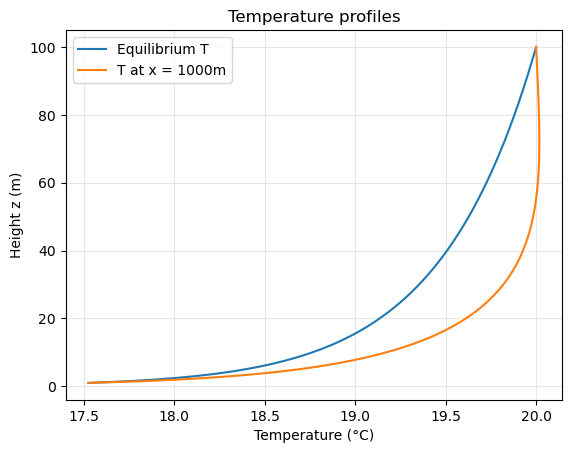

In [85]:
z = np.arange(params['zmin'] + params['dz'],
              params['zmax'] + params['dz'],
              params['dz'])

x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])

plt.plot(T_down[:200], z[:200], label="Equilibrium T")
plt.plot(T_uniform[-1][:200], z[:200], label="T at x = {0:.0f}m".format(x[-1]))

plt.xlabel("Temperature (°C)")   # change units if yours differ
plt.ylabel("Height z (m)")
plt.title("Temperature profiles")
plt.legend()
plt.grid(True, alpha=0.3)

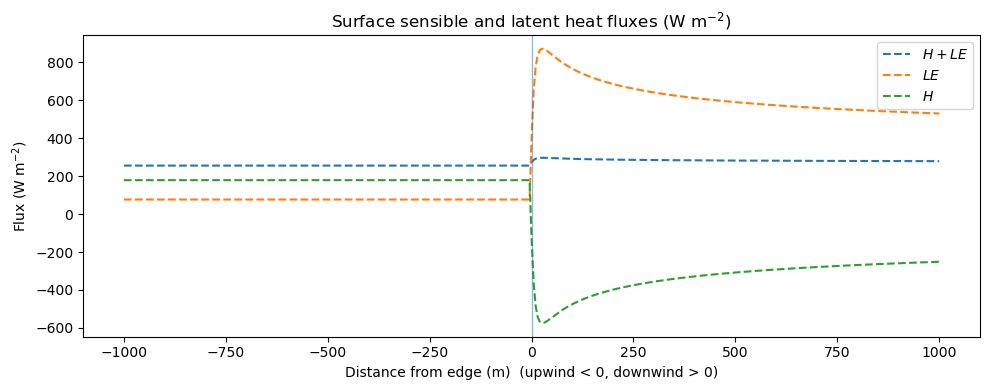

In [86]:

level = 5
dx = params["dx"]
nx = FluxTotal.shape[0]          # downwind length
xpos = np.arange(nx) * dx        # 0 ... xmax
xneg = -xpos[1:][::-1]           # -xmax ... -dx (no duplicate 0)
x_full = np.concatenate([xneg, xpos])

rho = 1.2
cp = 1005
Lv = 2.260e6
to_H  = rho * cp
to_LE = Lv / 1000
[z]
# downwind (x >= 0)
LE_down = FluxQ_uniform[:, level] * to_LE
H_down  = FluxT_uniform[:, level] * to_H
Tot_down = LE_down + H_down      # (or use FluxTotal[:, level] if it already matches units)

# upwind (x < 0): constant profiles at this level
LE_up = float(FluxQ_upwind[level]) * to_LE
H_up  = float(FluxT_upwind[level]) * to_H
Tot_up = LE_up + H_up

def stitch(up_const, down_array):
    up = np.full_like(xneg, up_const, dtype=float)
    return np.concatenate([up, down_array])

LE_full  = stitch(LE_up,  LE_down)
H_full   = stitch(H_up,   H_down)
Tot_full = stitch(Tot_up, Tot_down)

plt.figure(figsize=(10, 4))
ax = plt.gca()

ax.plot(x_full, Tot_full, ls="--", label=r"$H + LE$")
ax.plot(x_full, LE_full,  ls="--", label=r"$LE$")
ax.plot(x_full, H_full,   ls="--", label=r"$H$")

ax.axvline(0, lw=1, alpha=0.5)
ax.set_xlabel("Distance from edge (m)  (upwind < 0, downwind > 0)")
ax.set_ylabel("Flux (W m$^{-2}$)")
ax.set_title("Surface sensible and latent heat fluxes (W m$^{-2}$)")
# ax.set_ylim(0, max(Tot_full)*1.1)
ax.legend()
plt.tight_layout()



Text(0.5, 1.0, 'Advective enhancement')

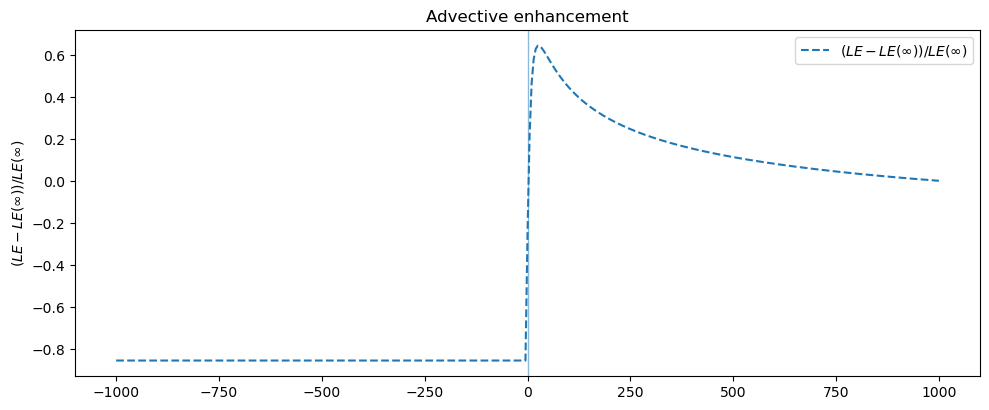

In [87]:


plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.plot(x_full, (LE_full - LE_full[-1])/LE_full[-1],  ls="--", label=r"$(LE - LE(\infty))/LE(\infty)$")
ax.axvline(0, lw=1, alpha=0.5)
ax.set_ylabel("$(LE - LE(\infty))/LE(\infty)$")
ax.legend()
plt.tight_layout()
ax.set_title("Advective enhancement")

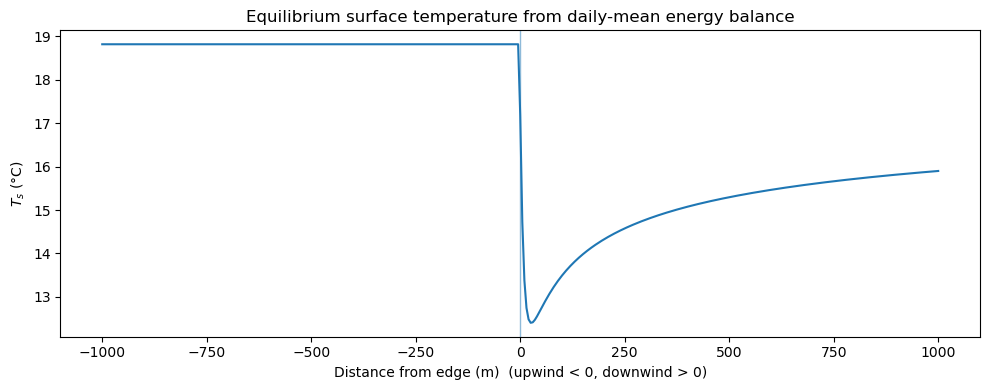

In [88]:
# --- equilibrium Ts from 1-day (G~0) surface energy balance ---
sigma = 5.670374419e-8

SW_in = params["SW_in"]          # daily-mean (or whatever mean you're using), W/m2
e_a   = params.get("e_a", 0.8)   # sky/atmos emissivity

# Choose albedo/emissivity by surface type (upwind=fallow, downwind=cultivated)
alpha = np.where(x_full < 0, params["alpha_f"], params["alpha_c"])
e_s   = np.where(x_full < 0, params.get("e_f", 0.95), params.get("e_c", 0.95))

# LW_in option A (simplest): use ambient air temperature
T_a = params["T_a"]  # °C
LW_in = e_a * sigma * (T_a + 273.15)**4
LW_in_full = np.full_like(x_full, LW_in, dtype=float)

# LW_in option B (more consistent with your column model): use modeled T at zmax
Tair_down = T_uniform[:, -1]                 # °C at top of column (downwind)
Tair_up   = T_uniform[0, -1]                 # °C at top of column (upwind profile at x=0)
Tair_full = stitch(Tair_up, Tair_down)
LW_in_full = e_a * sigma * (Tair_full + 273.15)**4

G = 0.0  # daily mean ground heat flux ~0; set to something else if desired

avail = (1 - alpha) * SW_in + LW_in_full - G          # energy available for LW_out + H + LE
LW_out_req = avail - Tot_full                          # what LW_out must be to close balance

#  if this goes <=0 anywhere, either forcing too small or sign convention mismatch
LW_out_req = np.maximum(LW_out_req, 1e-9)

Ts_eq = (LW_out_req / (e_s * sigma))**0.25 - 273.15    # °C

# quick plot
plt.figure(figsize=(10,4))
plt.plot(x_full, Ts_eq)
plt.axvline(0, lw=1, alpha=0.5)
plt.xlabel("Distance from edge (m)  (upwind < 0, downwind > 0)")
plt.ylabel(r"$T_s$ (°C)")
plt.title("Equilibrium surface temperature from daily-mean energy balance")
plt.tight_layout()

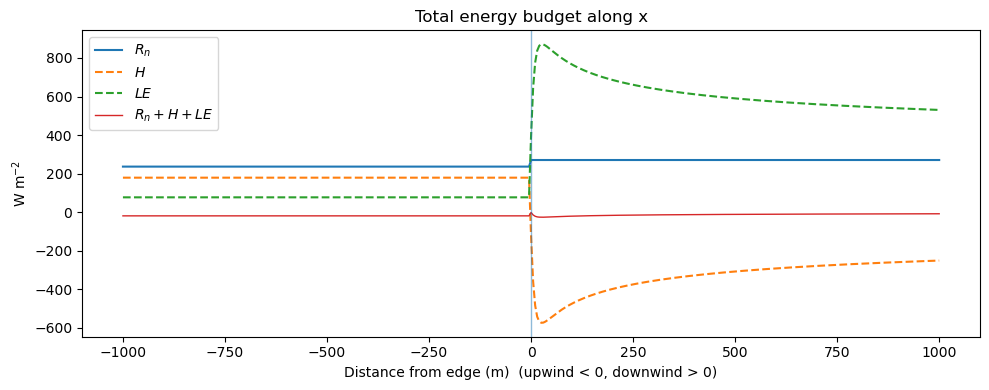

In [93]:
import numpy as np
import matplotlib.pyplot as plt

sigma = 5.670374419e-8

level = 5
dx = params["dx"]
nx = FluxTotal.shape[0]
xpos = np.arange(nx) * dx
xneg = -xpos[1:][::-1]
x_full = np.concatenate([xneg, xpos])

rho = 1.2
cp = 1005
Lv = 2.260e6
to_H  = rho * cp
to_LE = Lv / 1000

# -------------------------
# H, LE (your existing logic)
# -------------------------
LE_down = FluxQ_uniform[:, level] * to_LE
H_down  = FluxT_uniform[:, level] * to_H
Tot_down = LE_down + H_down

LE_up = float(FluxQ_upwind[level]) * to_LE
H_up  = float(FluxT_upwind[level]) * to_H
Tot_up = LE_up + H_up

def stitch(up_const, down_array):
    up = np.full_like(xneg, up_const, dtype=float)
    return np.concatenate([up, down_array])

LE_full  = stitch(LE_up,  LE_down)
H_full   = stitch(H_up,   H_down)
Tot_full = stitch(Tot_up, Tot_down)

# -------------------------
# Rn(x): you need Ts(x) at the surface
# -------------------------
# Pick the correct surface-temperature array from your code.
# Common patterns are T_uniform[:, 0] or T[:, 0] for z=0.
# Replace Ts_down with the right one.
Ts_down = T_uniform[:, 0]            # <-- CHANGE if your surface index differs
Ts_up   = float(T_up[0])         # <-- CHANGE if your upwind surface temp is stored differently

# Albedo/emissivity per patch (use your naming)
alpha_up = params["alpha_f"]
alpha_dn = params["alpha_c"]
eps_up   = params.get("e_f", 0.95)
eps_dn   = params.get("e_c", 0.95)

alpha_down = np.full(nx, alpha_dn, dtype=float)
eps_down   = np.full(nx, eps_dn,   dtype=float)

# LW_in: if you already built LW_in_full in your notebook, use that;
# otherwise (simple) compute from e_a and T_a:
e_a = params.get("e_a", 0.8)
T_a = params["T_a"]                  # °C
LW_in = e_a * sigma * (T_a + 273.15)**4

SW_in = params["SW_in"]              # W/m^2

Rn_down = (1 - alpha_down) * SW_in + LW_in - (eps_down * sigma * (Ts_down + 273.15)**4)
Rn_up   = (1 - alpha_up)  * SW_in + LW_in - (eps_up   * sigma * (Ts_up   + 273.15)**4)

Rn_full = stitch(Rn_up, Rn_down)

# -------------------------
# Total energy
# -------------------------
Etot_full = Rn_full - H_full - LE_full  # = Rn + H + LE

plt.figure(figsize=(10, 4))
ax = plt.gca()

ax.plot(x_full, Rn_full,   label=r"$R_n$")
ax.plot(x_full, H_full,    ls="--", label=r"$H$")
ax.plot(x_full, LE_full,   ls="--", label=r"$LE$")
ax.plot(x_full, Etot_full, lw=1, label=r"$R_n + H + LE$")

ax.axvline(0, lw=1, alpha=0.5)
ax.set_xlabel("Distance from edge (m)  (upwind < 0, downwind > 0)")
ax.set_ylabel("W m$^{-2}$")
ax.set_title("Total energy budget along x")
ax.legend()
plt.tight_layout()


In [111]:
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt

def _build_x_full(nx: int, dx: float):
    """
    Returns
    -------
    x_full : (2*nx-1,) array spanning upwind (negative) and downwind (>=0)
    xneg   : (nx-1,) upwind positions (negative, no 0)
    xpos   : (nx,)   downwind positions (includes 0)
    """
    xpos = np.arange(nx) * dx
    xneg = -xpos[1:][::-1]
    x_full = np.concatenate([xneg, xpos])
    return x_full, xneg, xpos

def _stitch_const_upwind(xneg, up_const: float, down_array: np.ndarray):
    up = np.full_like(xneg, float(up_const), dtype=float)
    return np.concatenate([up, np.asarray(down_array, dtype=float)])

def transition_diagnostics(params: dict, level: int = 5, return_profiles: bool = False):
    """
    One transition case: compute LE enhancement metrics + Δq metrics.

    enh(x) = (LE(x) - LE_inf)/LE_inf, where LE_inf is far-downwind LE.
    """
    # Equilibrium z-profiles (upwind and downwind)
    Q_up_eq,  FluxQ_upwind     = get_upwind_fluxQ(params)
    Q_down_eq, FluxQ_downwind  = get_downwind_fluxQ(params)

    # Downwind adjustment for a single transition
    Q_uniform, FluxQ_uniform = uniform_Q(params)

    nx = FluxQ_uniform.shape[0]
    dx = float(params["dx"])
    x_full, xneg, xpos = _build_x_full(nx, dx)

    # Report the physical height at "level"
    z = np.arange(params["zmin"] + params["dz"], 
                  params["zmax"] + params["dz"], params["dz"])
    z_level = float(z[level])

    # FluxQ is in [g m^-2 s^-1]; convert to LE [W m^-2]
    to_LE = 2.260e6 / 1000.0  # 2260 W per (g m^-2 s^-1)

    LE_down = np.asarray(FluxQ_uniform[:, level], dtype=float) * to_LE
    LE_inf = float(LE_down[-1])

    if LE_inf == 0.0 or (not np.isfinite(LE_inf)):
        enh_down = np.full_like(LE_down, np.nan, dtype=float)
        diff_down = np.full_like(LE_down, np.nan, dtype=float)
    else:
        enh_down = (LE_down - LE_inf) / LE_inf
        diff_down = (LE_down - LE_inf) / LE_inf
        
    # Scalar enhancement metrics (downwind only)
    peak_enh = float(np.nanmax(enh_down[:100]))
    edge_enh = float(enh_down[0])
    mean_enh = float(np.nanmean(enh_down[:100]))
    mean_diff = float(np.nanmean(diff_down[:100]))
    area_enh = float(np.trapz(np.maximum(enh_down, 0.0), xpos))  # meters

    # Δq metrics
    delta_q_surf = float(params["Q_c"] - params["Q_f"])                # g m^-3
    delta_q_level_eq  = float(Q_down_eq[level] - Q_up_eq[level])       # g m^-3 at z_level
    delta_q_level_far = float(Q_uniform[-1, level] - Q_up_eq[level])   # g m^-3 at z_level

    out = dict(
        level=level, 
        z_level=z_level,
        LE_inf=LE_inf,
        peak_enh=peak_enh, 
        edge_enh=edge_enh, 
        mean_enh=mean_enh, 
        mean_diff=mean_diff, 
        area_enh=area_enh,
        delta_q_surf=delta_q_surf,
        delta_q_level_eq=delta_q_level_eq,
        delta_q_level_far=delta_q_level_far,
    )

    if return_profiles:
        LE_up_const = float(FluxQ_upwind[level]) * to_LE
        LE_full = _stitch_const_upwind(xneg, LE_up_const, LE_down)

        if LE_inf == 0.0 or (not np.isfinite(LE_inf)):
            enh_full = np.full_like(LE_full, np.nan, dtype=float)
        else:
            enh_full = (LE_full - LE_inf) / LE_inf

        out.update(
            x_full=x_full, xneg=xneg, xpos=xpos,
            LE_down=LE_down, LE_full=LE_full,
            enh_down=enh_down, enh_full=enh_full,
        )
    return out

def sweep_grid(base_kwargs: dict, 
               grid: dict, 
               level: int = 5,
               delta_q_key: str = "delta_q_level_eq",
               enhance_key: str = "peak_enh"):
    """
    grid example:
      {"RH_c": np.linspace(20, 90, 15), "RH_a": [5, 10, 20]}
    """
    keys = list(grid.keys())
    values = [list(grid[k]) for k in keys]

    rows = []
    for vals in product(*values):
        case_kwargs = dict(base_kwargs)
        case_kwargs.update({k: v for k, v in zip(keys, vals)})

        # Important: rebuild params so Q_c, Q_f, Q_a, nx, etc stay consistent
        p = get_params(**case_kwargs)

        m = transition_diagnostics(p, level=level, return_profiles=False)

        row = {k: case_kwargs[k] for k in case_kwargs.keys()}
        row.update({
            "delta_q": m.get(delta_q_key, np.nan),
            "enhancement": m.get(enhance_key, np.nan),
            "mean_diff": m.get('mean_diff', np.nan),
        })
        row.update(m)
        rows.append(row)

    return pd.DataFrame(rows)

def plot_enh_vs_dq(df: pd.DataFrame, xcol="delta_q_level_eq", ycol="peak_enh"):
    """
    """
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.scatter(df[xcol], df[ycol])
    ax.set_xlabel(r"$\Delta q$ (g m$^{-3}$)")
    ax.set_ylabel("Advective enhancement (dimensionless)")
    ax.grid(True, alpha=0.3)
    if "z_level" in df.columns:
        ax.set_title(f"{ycol} vs {xcol}   (z ≈ {df['z_level'].iloc[0]:.2f} m)")
    else:
        ax.set_title(f"{ycol} vs {xcol}")
    plt.tight_layout()
    return fig, ax


level = 5  # same index you used in your LE plot

# Base case from your current params (if it exists); otherwise fill manually.
base_kwargs = dict(
    fallow_fraction=params.get("fallow_fraction", 0.5),
    fallow_length=params.get("fallow_length", 5000),
    Lx=params.get("Lx", 10000),    
    T_sc=params.get("T_sc", 28),
    T_sf=params.get("T_sf", 50),
    T_a=params.get("T_a", 18),
    RH_c=params.get("RH_c", 60),
    RH_f=params.get("RH_f", 10),
    RH_a=params.get("RH_a", 10),
    h=params.get("h", 2.3),
    zom_f=params.get("zom_f", 0.5),
    zom_c=params.get("zom_c", 0.5),
    SW_in=params.get("SW_in", 500),
    e_f=params.get("e_f", 0.95),
    e_c=params.get("e_c", 0.95),
    e_a=params.get("e_a", 0.8),
    alpha_c=params.get("alpha_c", 0.22),
    alpha_f=params.get("alpha_f", 0.22),
    lm_option=params.get("lm_option", "kz"),
)

grid = {"RH_c": np.linspace(30, 90, 15), "RH_f" : np.linspace(5, 20, 4)}
df = sweep_grid(base_kwargs, grid, level=level,
                delta_q_key="delta_q_level_eq",
                enhance_key="mean_enh")

df[["RH_c","delta_q_level_eq","peak_enh","edge_enh","area_enh"]].head()



,RH_c,delta_q_level_eq,peak_enh,edge_enh,area_enh
0,30.000000,1.512036,2.216542,-0.877893,579.503972
1,30.000000,0.989235,1.709644,-0.676880,446.979024
2,30.000000,0.466434,0.982240,-0.388424,256.804372
3,30.000000,-0.056366,0.060393,0.060393,0.150982
4,34.285714,1.802727,1.685525,-0.667315,440.673184


In [112]:
np.linspace(5, 20, 4)

array([ 5., 10., 15., 20.])

In [ ]:
import seaborn as sns
sns.scatterplot(df, x = 'delta_q_level_eq',y = 'mean_enh', hue = 'RH_f', palette = 'viridis')
plt.xlim(1, )

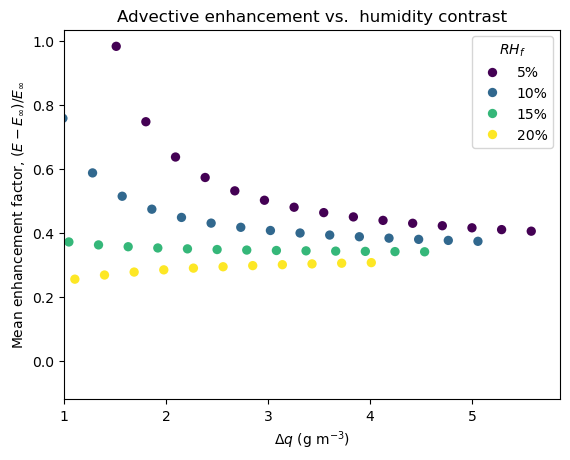

In [126]:
# import seaborn as sns
# sns.scatterplot(df, x = 'delta_q_level_eq',y = 'mean_enh', hue = 'RH_f', palette = 'viridis')
# plt.xlim(1, )

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

ax = sns.scatterplot(
    data=df,
    x="delta_q_level_eq",
    y="mean_enh",
    hue="RH_f",
    palette="viridis",
    s=45,
    edgecolor="none",
)
ax.set_xlim(1, )
ax.set_xlabel(r"$\Delta q$ (g m$^{-3}$)")  # adjust units if needed
ax.set_ylabel(r"Mean enhancement factor, $(E - E_\infty)/E_\infty$")  # or whatever mean_enh is
ax.set_title("Advective enhancement vs.  humidity contrast")

# nicer legend labels: RH_f -> percent
handles, labels = ax.get_legend_handles_labels()
new_labels = []
for lab in labels:
    try:
        new_labels.append(f"{float(lab):.0f}%")
    except ValueError:
        new_labels.append(lab)
ax.legend(handles=handles, labels=new_labels, title=r"$RH_f$")


In [142]:
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt

def _build_x_full(nx: int, dx: float):
    xpos = np.arange(nx) * dx
    xneg = -xpos[1:][::-1]
    x_full = np.concatenate([xneg, xpos])
    return x_full, xneg, xpos

def _stitch_const_upwind(xneg, up_const: float, down_array: np.ndarray):
    up = np.full_like(xneg, float(up_const), dtype=float)
    return np.concatenate([up, np.asarray(down_array, dtype=float)])

def _bisect_root(f, a, b, fa=None, fb=None, tol=0.1, max_iter=60):
    if fa is None: fa = float(f(a))
    if fb is None: fb = float(f(b))
    if np.sign(fa) == np.sign(fb):
        raise ValueError("Root not bracketed: f(a) and f(b) have same sign.")
    lo, hi = float(a), float(b)
    flo, fhi = float(fa), float(fb)
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        fmid = float(f(mid))
        if abs(fmid) <= tol:
            return mid, fmid
        if np.sign(fmid) == np.sign(flo):
            lo, flo = mid, fmid
        else:
            hi, fhi = mid, fmid
    return mid, fmid

def solve_T_sf_energy_balance(
    base_kwargs: dict,
    RH_f: float,
    T_sf_guess: float = None,
    T_sc_placeholder: float = 30.0,
    level: int = 5,
    tol_Wm2: float = 0.1,
):
    if T_sf_guess is None:
        T_sf_guess = float(base_kwargs.get("T_sf", base_kwargs.get("T_a", 20.0) + 10.0))

    def err(Tsf):
        p = get_params(**{**base_kwargs, "T_sf": Tsf, "T_sc": T_sc_placeholder, "RH_f": RH_f})
        e, *_ = adjust_T_sf(p, level=level)
        return e

    span = 25.0
    a = T_sf_guess - span
    b = T_sf_guess + span
    fa = float(err(a))
    fb = float(err(b))
    for _ in range(12):
        if np.sign(fa) != np.sign(fb):
            break
        span *= 1.5
        a = T_sf_guess - span
        b = T_sf_guess + span
        fa = float(err(a))
        fb = float(err(b))
    else:
        raise RuntimeError("Could not bracket T_sf root. Try different guesses/forcing.")

    T_sf, _ = _bisect_root(err, a, b, fa=fa, fb=fb, tol=tol_Wm2)

    p = get_params(**{**base_kwargs, "T_sf": T_sf, "T_sc": T_sc_placeholder, "RH_f": RH_f})
    error_f, Rn_f, SH_f, LH_f, *_ = adjust_T_sf(p, level=level)
    return float(T_sf), dict(error_f=error_f, Rn_f=Rn_f, SH_f=SH_f, LH_f=LH_f)

def solve_T_sc_energy_balance(
    base_kwargs: dict,
    RH_c: float,
    T_sf_fixed: float,
    T_sc_guess: float = None,
    level: int = 5,
    tol_Wm2: float = 0.1,
):
    if T_sc_guess is None:
        T_sc_guess = float(base_kwargs.get("T_sc", base_kwargs.get("T_a", 20.0) + 5.0))

    def err(Tsc):
        p = get_params(**{**base_kwargs, "T_sc": Tsc, "T_sf": T_sf_fixed, "RH_c": RH_c})
        e, *_ = adjust_T_sc(p, level=level)
        return e

    span = 25.0
    a = T_sc_guess - span
    b = T_sc_guess + span
    fa = float(err(a))
    fb = float(err(b))
    for _ in range(12):
        if np.sign(fa) != np.sign(fb):
            break
        span *= 1.5
        a = T_sc_guess - span
        b = T_sc_guess + span
        fa = float(err(a))
        fb = float(err(b))
    else:
        raise RuntimeError("Could not bracket T_sc root. Try different guesses/forcing.")

    T_sc, _ = _bisect_root(err, a, b, fa=fa, fb=fb, tol=tol_Wm2)

    p = get_params(**{**base_kwargs, "T_sc": T_sc, "T_sf": T_sf_fixed, "RH_c": RH_c})
    error_c, Rn_c, SH_c, LH_c, *_ = adjust_T_sc(p, level=level)
    return float(T_sc), dict(error_c=error_c, Rn_c=Rn_c, SH_c=SH_c, LH_c=LH_c)

def get_params_radiation_balance(
    base_kwargs: dict,
    RH_f: float,
    RH_c: float,
    level: int = 5,
    T_sf_guess: float = None,
    T_sc_guess: float = None,
    tol_Wm2: float = 0.1,
):
    T_sf, meta_f = solve_T_sf_energy_balance(
        base_kwargs=base_kwargs, RH_f=RH_f, T_sf_guess=T_sf_guess,
        T_sc_placeholder=float(base_kwargs.get("T_sc", 30.0)),
        level=level, tol_Wm2=tol_Wm2
    )
    T_sc, meta_c = solve_T_sc_energy_balance(
        base_kwargs=base_kwargs, RH_c=RH_c, T_sf_fixed=T_sf,
        T_sc_guess=T_sc_guess, level=level, tol_Wm2=tol_Wm2
    )

    params = get_params(**{**base_kwargs, "T_sf": T_sf, "T_sc": T_sc, "RH_f": RH_f, "RH_c": RH_c})
    meta = {"T_sf": T_sf, "T_sc": T_sc, **meta_f, **meta_c}
    return params, meta

def transition_diagnostics_radb(
    base_kwargs: dict,
    RH_f: float,
    RH_c: float,
    level: int = 5,
    return_profiles: bool = False,
    delta_q_def: str = "level_eq",
    enh_def: str = "peak",
):
    params, meta = get_params_radiation_balance(base_kwargs, RH_f=RH_f, RH_c=RH_c, level=level)

    # Transition moisture solve
    Q_uniform, FluxQ_uniform = uniform_Q(params)

    # FluxQ [g m^-2 s^-1] -> LE [W m^-2]
    to_LE = 2.260e6 / 1000.0
    LE_down = np.asarray(FluxQ_uniform[:, level], dtype=float) * to_LE
    LE_inf = float(LE_down[-1])
    enh_down = (LE_down - LE_inf) / LE_inf if LE_inf != 0 else np.full_like(LE_down, np.nan)

    nx = FluxQ_uniform.shape[0]
    dx = float(params["dx"])
    x_full, xneg, xpos = _build_x_full(nx, dx)

    peak_enh = float(np.nanmax(enh_down))
    edge_enh = float(enh_down[0])
    mean_enh = float(np.nanmean(enh_down))
    area_enh = float(np.trapz(np.maximum(enh_down, 0.0), xpos))

    enh_map = dict(peak=peak_enh, edge=edge_enh, mean=mean_enh, area=area_enh)
    enhancement = enh_map.get(enh_def, peak_enh)

    # Δq options
    Q_up_eq, _   = get_upwind_fluxQ(params)
    Q_down_eq, _ = get_downwind_fluxQ(params)

    if delta_q_def == "surf":
        delta_q = float(params["Q_c"] - params["Q_f"])
    elif delta_q_def == "level_far":
        delta_q = float(Q_uniform[-1, level] - Q_up_eq[level])
    else:  # "level_eq"
        delta_q = float(Q_down_eq[level] - Q_up_eq[level])

    out = dict(
        RH_f=RH_f, RH_c=RH_c,
        T_sf=meta["T_sf"], T_sc=meta["T_sc"],
        delta_q=delta_q,
        enhancement=enhancement,
        LE_inf=LE_inf,
        peak_enh=peak_enh, edge_enh=edge_enh, mean_enh=mean_enh, area_enh=area_enh,
        delta_q_surf=float(params["Q_c"] - params["Q_f"]),
        delta_q_level_eq=float(Q_down_eq[level] - Q_up_eq[level]),
        delta_q_level_far=float(Q_uniform[-1, level] - Q_up_eq[level]),
        **{k:v for k,v in meta.items() if k not in ["T_sf","T_sc"]},
    )

    if return_profiles:
        LE_up_const = float(get_upwind_fluxQ(params)[1][level]) * to_LE
        LE_full = _stitch_const_upwind(xneg, LE_up_const, LE_down)
        enh_full = (LE_full - LE_inf) / LE_inf if LE_inf != 0 else np.full_like(LE_full, np.nan)
        out.update(x_full=x_full, LE_full=LE_full, enh_full=enh_full)

    return out

def sweep_grid_radb(
    base_kwargs: dict,
    grid: dict,
    level: int = 5,
    delta_q_def: str = "level_eq",
    enh_def: str = "peak",
):
    keys = list(grid.keys())
    values = [list(grid[k]) for k in keys]
    rows = []
    for vals in product(*values):
        case = dict(zip(keys, vals))
        RH_f = float(case.get("RH_f", base_kwargs.get("RH_f", 10.0)))
        RH_c = float(case.get("RH_c", base_kwargs.get("RH_c", 60.0)))

        base = dict(base_kwargs)
        base.update({k: v for k, v in case.items() if k not in ["RH_f", "RH_c"]})

        d = transition_diagnostics_radb(
            base_kwargs=base, RH_f=RH_f, RH_c=RH_c,
            level=level, return_profiles=False,
            delta_q_def=delta_q_def, enh_def=enh_def
        )
        d.update(case)
        rows.append(d)
    return pd.DataFrame(rows)

def plot_enh_vs_dq(df, xcol="delta_q", ycol="enhancement"):
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.scatter(df[xcol], df[ycol])
    ax.set_xlabel(r"$\Delta q$ (g m$^{-3}$)")
    ax.set_ylabel("Advective enhancement (dimensionless)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax

(<Figure size 650x400 with 1 Axes>,
 <Axes: xlabel='$\\Delta q$ (g m$^{-3}$)', ylabel='Advective enhancement (dimensionless)'>)

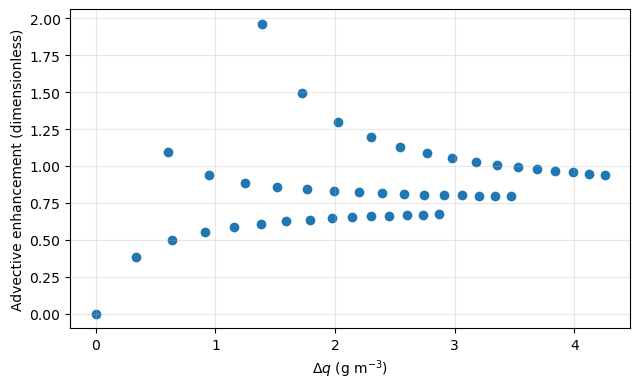

In [146]:
level = 5

base_kwargs = dict(
    # geometry/flow
    fallow_fraction=0.5,
    fallow_length=500,
    Lx=1000,
    h=2.3,
    zom_f=0.5,
    zom_c=0.5,
    lm_option="kz",

    # forcing / radiation terms
    SW_in=400,
    e_a=0.8, e_f=0.95, e_c=0.95,
    alpha_f=0.22, alpha_c=0.22,

    # air state
    T_a=20,
    RH_a=20,

    # initial guesses (only used for bracketing the energy-balance solve)
    T_sf=30,
    T_sc=28,

    # defaults (overridden by sweep if provided)
    RH_f=20,
    RH_c=60,
)

df = sweep_grid_radb(
    base_kwargs,
    grid={"RH_c": np.linspace(20, 90, 15), "RH_f": np.linspace(5, 20, 3)},  # sweep crop RH
    level=level,
    delta_q_def="level_eq",   # or "surf" or "level_far"
    enh_def="peak",           # or "edge" or "mean" or "area"
)

df[["RH_c", "T_sf", "T_sc", "delta_q_level_eq", "peak_enh"]].head()

plot_enh_vs_dq(df, xcol="delta_q_level_eq", ycol="peak_enh")

In [127]:
# def ET_enhance(FluxQ_uniform, FluxQ_fallow, FluxQ, params):
    
#     dx = params['dx']
#     nx = params['nx']    
#     Q_c = params['Q_c']
#     Q_f = params['Q_f']    
#     Qs_array = populate_Qc_array(params)
    
#     continuous_cultivation = FluxQ_uniform[nx-1, 0]*dx
    
#     uniform_flux = FluxQ_uniform[nx-1, level]*(Qs_array > Q_f).mean() + \
#                 FluxQ_fallow[nx-1, level]*(Qs_array == Q_f).mean()
#     uniform_flux = uniform_flux*dx
    
#     FluxQ_force = FluxQ.copy()
#     FluxQ_force[Qs_array < Q_c] = FluxQ_fallow[-1,level]
    
#     return  continuous_cultivation, uniform_flux, FluxQ_force[:, level].mean()*dx


In [128]:
# Helper to build spatial pattern of surface water vapor concentration
# (Copied/adapted from other notebooks to avoid duplication errors)
def populate_Qc_array(params):
    """
    Return array of surface (patch) water vapor concentrations along x.

    Pattern: repeating cultivated (Q_c) and fallow (Q_f) segments whose
    relative lengths are set by fallow_fraction and fallow_length in params.
    Result length equals nx.
    """
    nx = params['nx']
    dx = params['dx']
    fallow_length = params['fallow_length']
    fallow_fraction = params['fallow_fraction']


    # Total cycle length (one cultivated + one fallow block) scaled so that
    # fallow occupies specified fraction of pattern length.
    # Let L_f = fallow_length (given). Then cultivated length L_c satisfies:
    # L_f / (L_f + L_c) = fallow_fraction  => L_c = L_f * (1 - f)/f
    L_f = fallow_length + 1
    f = fallow_fraction if fallow_fraction > 0 else 0.5
    L_c = L_f * (1 - f) / f
    cycle = L_f + L_c

    x = np.arange(params['xmin'], params['xmax'] + dx, dx)[:nx]
    pattern = np.empty(nx)
    for i, xx in enumerate(x):
        # Position within cycle
        x_mod = xx % cycle
        # Assign fallow first (could swap ordering if desired)
        if x_mod < L_f:
            pattern[i] = 0
        else:
            pattern[i] = 1
    return pattern


In [129]:
Qs_array = populate_Qc_array(params)

ustar = params['ustar_f']
dz = params['dz']
Q, FluxQ = varying_Qs(params)


In [130]:
FluxQ_no_adv = np.ones_like(FluxQ)
FluxQ_no_adv[Qs_array == 1] = FluxQ_downwind
FluxQ_no_adv[Qs_array == 0] = FluxQ_upwind

Q_no_adv = np.ones_like(Q)
Q_no_adv[Qs_array == 0] = Q_up
Q_no_adv[Qs_array == 1] = Q_down


FluxQ_continuous = np.ones_like(FluxQ)
FluxQ_continuous[Qs_array >= 0] = FluxQ_downwind

Q_continuous = np.ones_like(Q)
Q_continuous[Qs_array == 1] = Q_down


Q_norm = np.sum(Q - Q_up, axis=1) * dz
Q_no_adv_norm = np.sum(Q_no_adv - Q_up, axis = 1) * dz


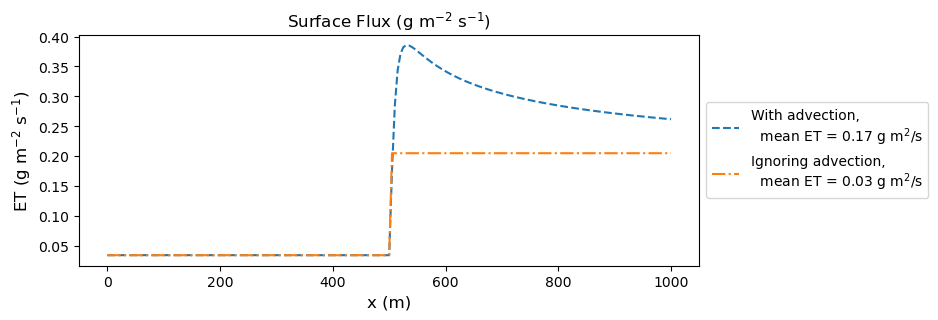

In [131]:
dz = params['dz']
dx = params['dx']

nx = params['nx']
nz = params['nz']

Q_a = params['Q_a']
Q_c = params['Q_c']
Q_f = params['Q_f']

plt.figure(figsize = (8, 3))
ax = plt.gca()

plt.plot(x, FluxQ[:, level], '--',  
         label = "With advection, \n  mean ET = {0:.2f} g m$^2$/s".format(
         FluxQ[:, level].mean()))

plt.plot(x, FluxQ_no_adv[:, level], '-.', 
         label = "Ignoring advection, \n  mean ET = {0:.2f} g m$^2$/s".format(FluxQ_no_adv[level].mean()))


plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('ET (g m$^{-2}$ s$^{-1}$)', fontsize=12, fontweight='normal')
plt.title('Surface Flux (g m$^{-2}$ s$^{-1}$)', fontsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))



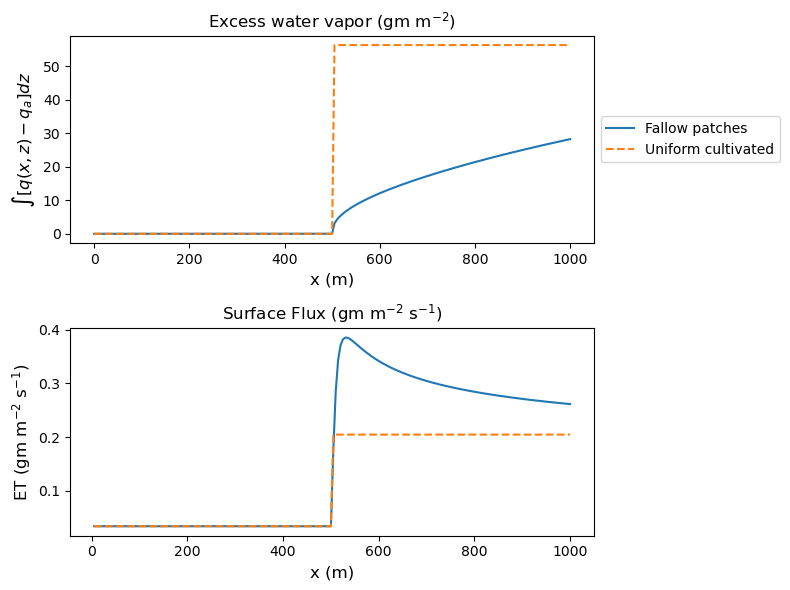

In [132]:

# Plot excess water vapor and surface flux
plt.figure(figsize = (8, 6))
plt.subplot(2, 1, 1)
plt.plot(x, Q_norm, '-', label = 'Fallow patches')
plt.plot(x, Q_no_adv_norm, '--', label = 'Uniform cultivated')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel(r'$\int [q(x,z) - q_a]dz$', fontsize=12, fontweight='normal')
plt.title('Excess water vapor (gm m$^{-2}$)', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.subplot(2, 1, 2)
plt.plot(x[1:], FluxQ[1:, level], '-')
plt.plot(x[1:], FluxQ_no_adv[1:, level], '--')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('ET (gm m$^{-2}$ s$^{-1}$)', fontsize=12, fontweight='normal')
plt.title('Surface Flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()


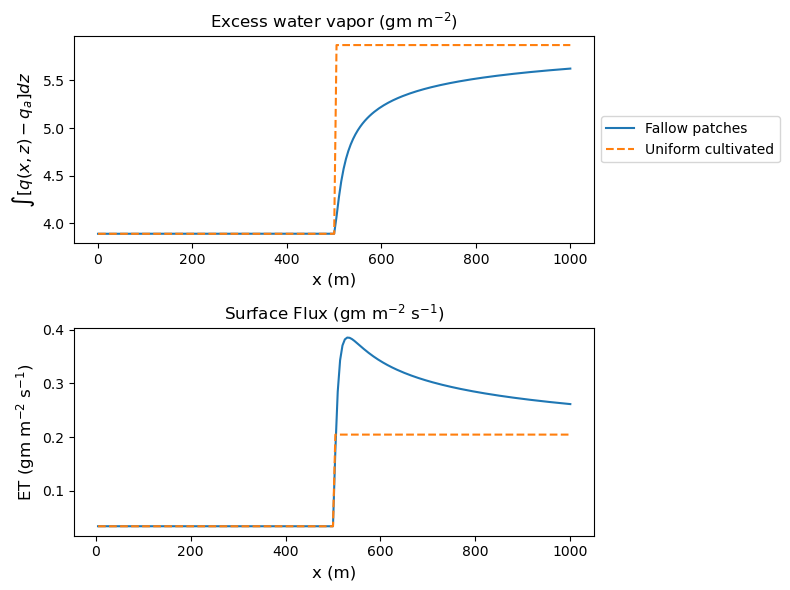

In [133]:
# Plot excess water vapor and surface flux
plt.figure(figsize = (8, 6))
plt.subplot(2, 1, 1)
plt.plot(x, Q[:, level], '-', label = 'Fallow patches')
plt.plot(x, Q_no_adv[:, level], '--', label = 'Uniform cultivated')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel(r'$\int [q(x,z) - q_a]dz$', fontsize=12, fontweight='normal')
plt.title('Excess water vapor (gm m$^{-2}$)', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.subplot(2, 1, 2)
plt.plot(x[1:], FluxQ[1:, level], '-')
plt.plot(x[1:], FluxQ_no_adv[1:, level], '--')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('ET (gm m$^{-2}$ s$^{-1}$)', fontsize=12, fontweight='normal')
plt.title('Surface Flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()
# plt.ylim(0, )


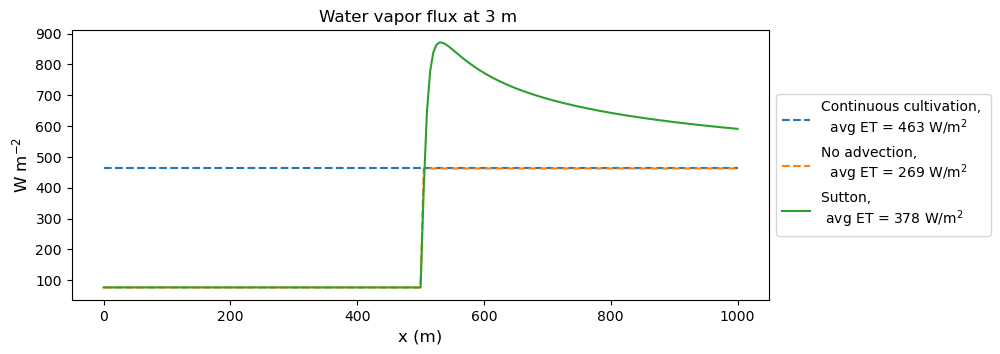

In [134]:
plt.figure(figsize = (9, 3.5))
ax = plt.gca()

ax.plot(x[:],  FluxQ_continuous[:, level]*2260, '--',  
         label = "Continuous cultivation, \n  avg ET = {0:.0f} W/m$^2$".format(
             FluxQ_continuous[nx-1, level]*2260))


ax.plot(x[:], FluxQ_no_adv[:, level]*2260, '--',  
         label = "No advection, \n  avg ET = {0:.0f} W/m$^2$".format(
             FluxQ_no_adv[:, level].mean()*2260))

plt.plot(x[:], FluxQ[:, level]*2260, '-', label = "Sutton,  \n avg ET = {0:.0f} W/m$^2$".format(
    FluxQ[:, level].mean()*2260))

plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('W m$^{-2}$', fontsize=12, fontweight='normal')
plt.title('Water vapor flux at 3 m ', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

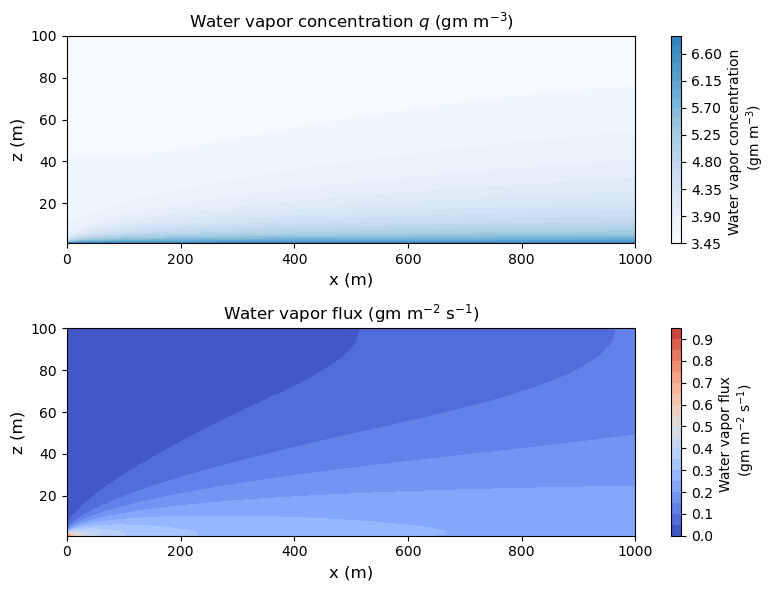

In [135]:
z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], params['dz'])
x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])

# Plot water vapor concentration and vertical flux
plt.figure(figsize = (8, 6))

plt.subplot(2, 1, 1)
plt.contourf(x, z, (Q_uniform.T), 25, cmap='Blues',  vmax = Q_c, vmin = Q_a)
plt.colorbar(label='Water vapor concentration \n (gm m$^{-3}$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (gm m$^{-3}$)', fontsize=12)

plt.subplot(2, 1, 2)
plt.contourf(x, z, FluxQ_uniform.T.round(4),  20, cmap='coolwarm', vmin = 0, vmax = 1)
plt.colorbar(label='Water vapor flux \n (gm m$^{-2}$ s$^{-1}$)') 
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()



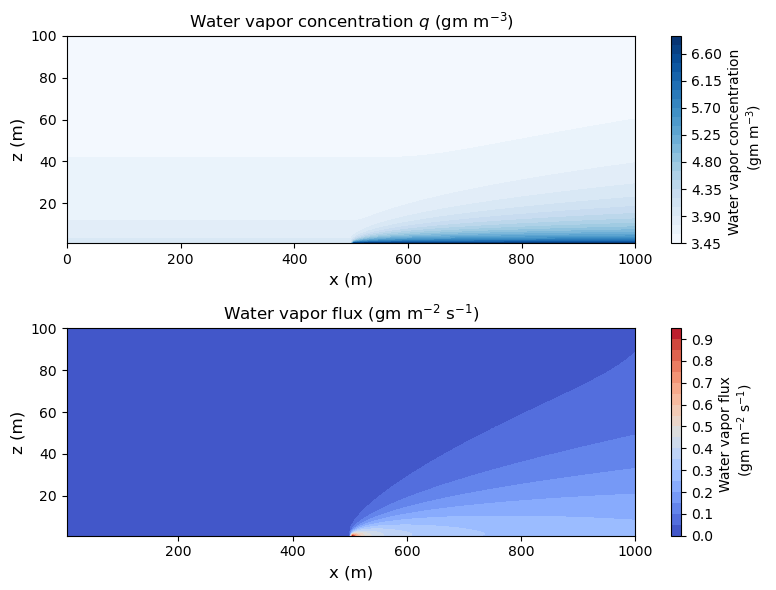

In [136]:
z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], params['dz'])
x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])

# Plot water vapor concentration and vertical flux
plt.figure(figsize = (8, 6))

plt.subplot(2, 1, 1)
plt.contourf(x, z, (Q.T), 25, cmap='Blues',  )#vmax = Q_f, vmin = Q_a)
plt.colorbar(label='Water vapor concentration \n (gm m$^{-3}$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (gm m$^{-3}$)', fontsize=12)

plt.subplot(2, 1, 2)
plt.contourf(x[1:], z, FluxQ[1:].T.round(4),  20, cmap='coolwarm')
plt.colorbar(label='Water vapor flux \n (gm m$^{-2}$ s$^{-1}$)') 
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()


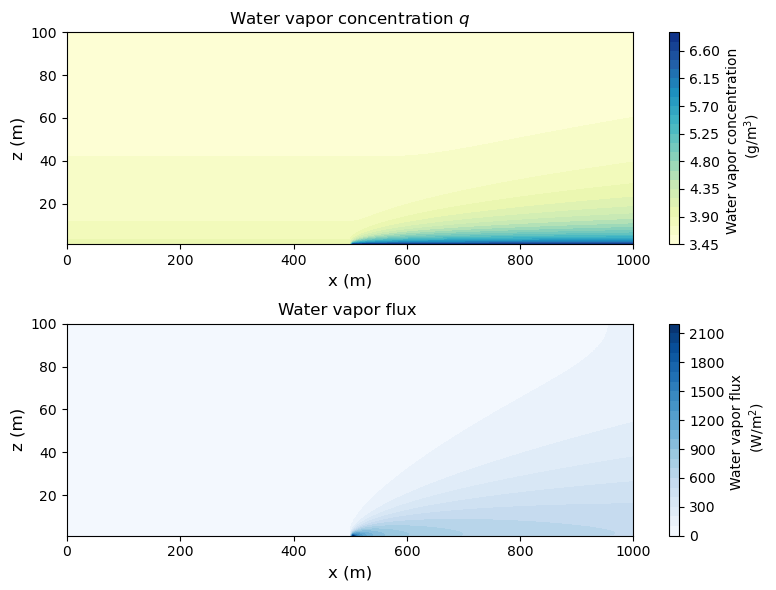

In [137]:
# Plot water vapor concentration and vertical flux
plt.figure(figsize = (8, 6))

# Normalized concentration (if needed)
# Qd = (Q - Qa) / (Qs - Qa)
blues = ['#ffffd9','#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84']
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list('custom_blues', blues)

plt.subplot(2, 1, 1)
plt.contourf(x, z, (Q.T), 25, cmap=custom_cmap)
plt.colorbar(label='Water vapor concentration \n (g/m$^3$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ ', fontsize=12)

plt.subplot(2, 1, 2)

plt.contourf(x, z, FluxQ.T.round(4)*2260,  20, cmap='Blues') 
plt.colorbar(label='Water vapor flux \n (W/m$^2$)') 
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux ', fontsize=12)

plt.tight_layout()
plt.show()


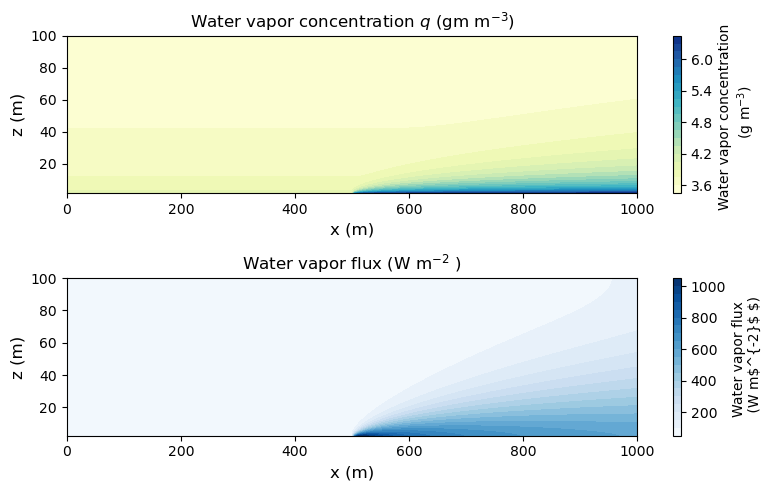

In [138]:
# Reduce the number of tick labels for colorbars
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

# Create custom colormap
blues = ['#ffffd9','#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84']
custom_cmap = LinearSegmentedColormap.from_list('custom_blues', blues)

plt.figure(figsize=(8,5))

# Subplot 1: Water vapor concentration
plt.subplot(2, 1, 1)
contour1 = plt.contourf(x, z[1:], Q[:, 1:].T, 25, cmap=custom_cmap)
cbar1 = plt.colorbar(contour1, label='Water vapor concentration \n (g m$^{-3}$)')
cbar1.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))  # Reduce tick labels
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (gm m$^{-3}$)', fontsize=12)

# Subplot 2: Water vapor flux
plt.subplot(2, 1, 2)
contour2 = plt.contourf(x, z[3:], FluxQ[:, 3:].T.round(4)*2260, 20, cmap='Blues')
cbar2 = plt.colorbar(contour2, label='Water vapor flux \n (W m$^{-2}$ $)')
cbar2.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))  # Reduce tick labels
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (W m$^{-2}$ )', fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'y=(Q-Q_a)/(Q_s-Q_a)')

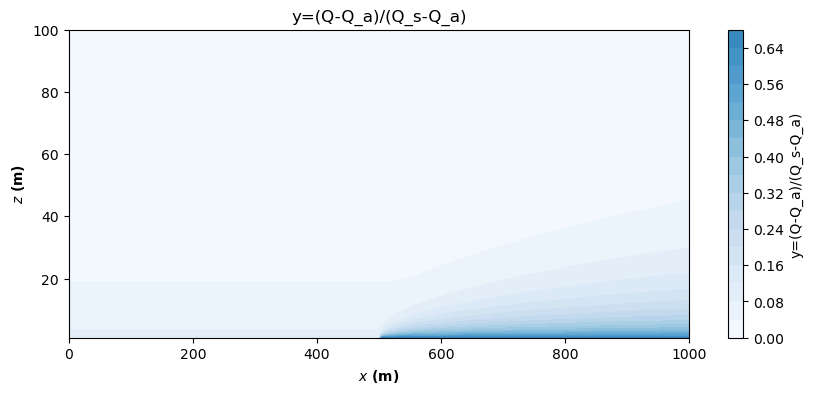

In [139]:

# Normalized concentration
Q_d = (Q - Q_a) / (Q_c - Q_a)

plt.figure(3, figsize = (10,4))
plt.clf()
plt.contourf(x, z, Q_d.T, 20, vmax =1, cmap='Blues')
plt.xlabel(r'$\it{x}$ (m)', fontweight='bold', fontsize=10)
plt.ylabel(r'$\it{z}$ (m)', fontweight='bold', fontsize=10)
plt.colorbar(label='y=(Q-Q_a)/(Q_s-Q_a)')
plt.title('y=(Q-Q_a)/(Q_s-Q_a)')


In [140]:
X, Z = np.meshgrid(x, z)


Text(0.5, 0.92, 'Water Vapor Flux (gm m$^{-2}$ s$^{-1}$)')

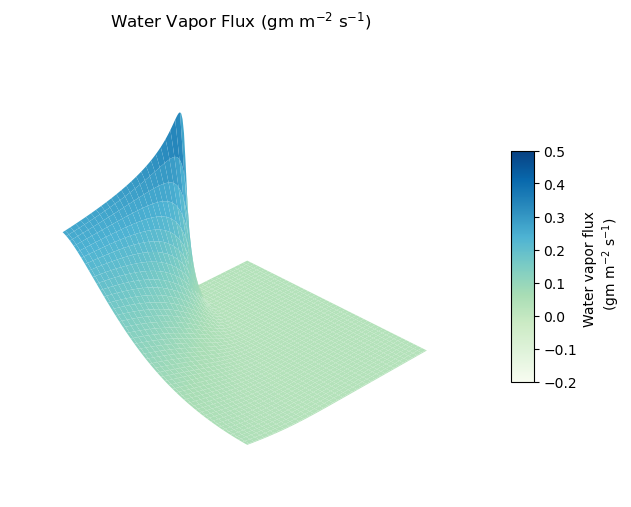

In [141]:
# Create a 3D plot with axes turned off
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X[5:, 50:],Z[5:, 50:], FluxQ.T[5:, 50:], cmap='GnBu', vmin=-0.2, vmax=0.5)

# Add color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Water vapor flux \n (gm m$^{-2}$ s$^{-1}$)', fontsize=10)
ax.view_init(elev=30, azim=45)
# Turn off axes
ax.axis('off')

# Set title
ax.set_title('Water Vapor Flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)


## Bruetsaert emissivity problems

$  \epsilon_a (T_a) = 1.24 \bigg( \frac{e_{sat}(T_a)\cdot RH/100}{T_a}\bigg)^{1/7}$




In [32]:
params['RH_a'], params['T_a'], e_sat(20)
T_a = 20
RH_a = 10
1.24*(e_sat( T_a)*RH_a/100/ (T_a+273.15))**(1/7)


1.200588261094191

In [33]:
params['Q_a']

3.497807344031757